#**Week # 04 - Internship**


# **PART A — DATA PREPARATION & BASELINE MODEL**

# **Step # 01:  Environment Setup & Week 3 Data Pipeline**

In [431]:
import pandas as pd
import numpy as np


In [432]:
# Machine Learning Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
# Feature Engineering
from sklearn.preprocessing import(
    PolynomialFeatures,
    StandardScaler
)
from sklearn.pipeline import Pipeline

# Model Selection & Validation
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    KFold,
    learning_curve
)

# Evaluation Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [433]:
df = pd.read_csv("/content/train.csv")

df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
961,962,60,RL,NaN,12227,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,272000
180,181,160,FV,NaN,2117,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,177000
281,282,20,FV,60.0,7200,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2006,New,Partial,185000
1303,1304,20,RL,73.0,8688,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,232000
133,134,20,RL,NaN,6853,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,220000


In [434]:
df.shape

(1460, 81)

In [435]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [436]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [437]:
# Standardize column names
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

# Display updated columns
print(df.columns.tolist())

['id', 'mssubclass', 'mszoning', 'lotfrontage', 'lotarea', 'street', 'alley', 'lotshape', 'landcontour', 'utilities', 'lotconfig', 'landslope', 'neighborhood', 'condition1', 'condition2', 'bldgtype', 'housestyle', 'overallqual', 'overallcond', 'yearbuilt', 'yearremodadd', 'roofstyle', 'roofmatl', 'exterior1st', 'exterior2nd', 'masvnrtype', 'masvnrarea', 'exterqual', 'extercond', 'foundation', 'bsmtqual', 'bsmtcond', 'bsmtexposure', 'bsmtfintype1', 'bsmtfinsf1', 'bsmtfintype2', 'bsmtfinsf2', 'bsmtunfsf', 'totalbsmtsf', 'heating', 'heatingqc', 'centralair', 'electrical', '1stflrsf', '2ndflrsf', 'lowqualfinsf', 'grlivarea', 'bsmtfullbath', 'bsmthalfbath', 'fullbath', 'halfbath', 'bedroomabvgr', 'kitchenabvgr', 'kitchenqual', 'totrmsabvgrd', 'functional', 'fireplaces', 'fireplacequ', 'garagetype', 'garageyrblt', 'garagefinish', 'garagecars', 'garagearea', 'garagequal', 'garagecond', 'paveddrive', 'wooddecksf', 'openporchsf', 'enclosedporch', '3ssnporch', 'screenporch', 'poolarea', 'poolqc'

In [438]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Number of Numerical Columns:", len(num_cols))
print("Number of Categorical Columns:", len(cat_cols))

Number of Numerical Columns: 38
Number of Categorical Columns: 43


In [439]:
# Fill numeric missing values with median
for col in num_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

print("Numeric missing values handled.")

Numeric missing values handled.


In [440]:
# Fill categorical missing values with mode
for col in cat_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

print("Categorical missing values handled.")

Categorical missing values handled.


# **Step # 02: Feature Selection & Target Preparation**

In [441]:
# Correlation with saleprice
correlation = df.corr(numeric_only=True)['saleprice']

# Sort correlations descending
correlation_sorted = correlation.sort_values(ascending=False)

print(correlation_sorted.head(25))

saleprice       1.000000
overallqual     0.790982
grlivarea       0.708624
garagecars      0.640409
garagearea      0.623431
totalbsmtsf     0.613581
1stflrsf        0.605852
fullbath        0.560664
totrmsabvgrd    0.533723
yearbuilt       0.522897
yearremodadd    0.507101
masvnrarea      0.472614
fireplaces      0.466929
garageyrblt     0.466754
bsmtfinsf1      0.386420
lotfrontage     0.334771
wooddecksf      0.324413
2ndflrsf        0.319334
openporchsf     0.315856
halfbath        0.284108
lotarea         0.263843
bsmtfullbath    0.227122
bsmtunfsf       0.214479
bedroomabvgr    0.168213
screenporch     0.111447
Name: saleprice, dtype: float64


In [442]:
# Features to exclude
exclude_features = ['saleprice', 'pricepersf']

# Remove excluded features
correlation_filtered = correlation_sorted.drop(
    labels=[col for col in exclude_features if col in correlation_sorted.index],
    errors='ignore'
)

In [443]:
# Select top 20 correlated features
top_20_features = correlation_filtered.head(20).index.tolist()

print("Top 20 Features:")
print(top_20_features)

Top 20 Features:
['overallqual', 'grlivarea', 'garagecars', 'garagearea', 'totalbsmtsf', '1stflrsf', 'fullbath', 'totrmsabvgrd', 'yearbuilt', 'yearremodadd', 'masvnrarea', 'fireplaces', 'garageyrblt', 'bsmtfinsf1', 'lotfrontage', 'wooddecksf', '2ndflrsf', 'openporchsf', 'halfbath', 'lotarea']


In [444]:
# Store original target
y_original = df['saleprice']

In [445]:
# Skewness before log transform
skew_before = df['saleprice'].skew()

print("Target Skewness Before Log Transform:")
print(skew_before)

Target Skewness Before Log Transform:
1.8828757597682129


In [446]:
# Apply log transformation
y = np.log1p(df['saleprice'])
y

,saleprice
0,12.247699
1,12.109016
2,12.317171
3,11.849405
4,12.429220
...,...
1455,12.072547
1456,12.254868
1457,12.493133
1458,11.864469


In [447]:
# Skewness after transform
skew_after = y.skew()

print("Target Skewness After Log Transform:")
print(skew_after)

Target Skewness After Log Transform:
0.12134661989685333


In [448]:
# Create feature matrix
X = df[top_20_features]
X

,overallqual,grlivarea,garagecars,garagearea,totalbsmtsf,1stflrsf,fullbath,totrmsabvgrd,yearbuilt,yearremodadd,masvnrarea,fireplaces,garageyrblt,bsmtfinsf1,lotfrontage,wooddecksf,2ndflrsf,openporchsf,halfbath,lotarea
0,7,1710,2,548,856,856,2,8,2003,2003,196.0,0,2003.0,706,65.0,0,854,61,1,8450
1,6,1262,2,460,1262,1262,2,6,1976,1976,0.0,1,1976.0,978,80.0,298,0,0,0,9600
2,7,1786,2,608,920,920,2,6,2001,2002,162.0,1,2001.0,486,68.0,0,866,42,1,11250
3,7,1717,3,642,756,961,1,7,1915,1970,0.0,1,1998.0,216,60.0,0,756,35,0,9550
4,8,2198,3,836,1145,1145,2,9,2000,2000,350.0,1,2000.0,655,84.0,192,1053,84,1,14260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,460,953,953,2,7,1999,2000,0.0,1,1999.0,0,62.0,0,694,40,1,7917
1456,6,2073,2,500,1542,2073,2,7,1978,1988,119.0,2,1978.0,790,85.0,349,0,0,0,13175
1457,7,2340,1,252,1152,1188,2,9,1941,2006,0.0,2,1941.0,275,66.0,0,1152,60,0,9042
1458,5,1078,1,240,1078,1078,1,5,1950,1996,0.0,0,1950.0,49,68.0,366,0,0,0,9717


In [449]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1460, 20)
Shape of y: (1460,)



# **Step # 03: Train-Test Split & Scaling**

In [450]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [451]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [452]:
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (1168, 20)
X_test Shape : (292, 20)
y_train Shape: (1168,)
y_test Shape : (292,)


In [453]:
# Create scaler
scaler = StandardScaler()

In [454]:
# Fit scaler on training data
scaler.fit(X_train)

StandardScaler()

In [455]:
# Transform training data
X_train_scaled = scaler.transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

In [456]:
# Mean of scaled training data
train_mean = X_train_scaled.mean(axis=0)

# Standard deviation of scaled training data
train_std = X_train_scaled.std(axis=0)

print("Training Mean (Approx 0):")
print(np.round(train_mean, 4))

print("\nTraining Std (Approx 1):")
print(np.round(train_std, 4))

Training Mean (Approx 0):
[-0. -0.  0.  0.  0. -0. -0. -0. -0.  0. -0.  0.  0.  0.  0. -0.  0.  0.
 -0.  0.]

Training Std (Approx 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [457]:
# Mean of scaled test data
test_mean = X_test_scaled.mean(axis=0)

# Standard deviation of scaled test data
test_std = X_test_scaled.std(axis=0)

print("Test Mean:")
print(np.round(test_mean, 4))

print("\nTest Std:")
print(np.round(test_std, 4))

Test Mean:
[-0.0814 -0.1139 -0.0984 -0.0781 -0.0493 -0.087  -0.1096 -0.1354  0.0493
 -0.0076 -0.0035 -0.0398 -0.0305 -0.026  -0.0513 -0.0657 -0.061  -0.2103
  0.0103 -0.0803]

Test Std:
[1.0529 1.0052 1.0442 1.0607 0.9769 0.9963 1.0319 1.0106 0.9198 0.9789
 1.214  0.9962 0.9904 0.9673 0.8967 0.8172 0.9638 0.7199 1.0294 0.5464]



# **Step # 04: Write the evaluate_model() Utility Function**

In [458]:
from typing import Dict, Any
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [459]:
def evaluate_model(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
    n_features: int
) -> Dict[str, Any]:
    """
    Evaluate regression model performance using multiple metrics.

    Parameters
    ----------
    y_true : np.ndarray
        Actual target values.

    y_pred : np.ndarray
        Predicted target values generated by the model.

    model_name : str
        Name of the regression model being evaluated.

    n_features : int
        Number of independent features used in the model.

    Returns
    -------
    Dict[str, Any]
        Dictionary containing all evaluation metrics:
        - MAE
        - MSE
        - RMSE
        - R²
        - Adjusted R²
        - MAPE

    Notes
    -----
    The function prints all evaluation metrics and returns
    them in dictionary format for later comparison.
    """

    # Total number of observations
    n = len(y_true)

    # Mean Absolute Error
    mae = mean_absolute_error(y_true, y_pred)

    # Mean Squared Error
    mse = mean_squared_error(y_true, y_pred)

    # Root Mean Squared Error
    rmse = np.sqrt(mse)

    # R-squared Score
    r2 = r2_score(y_true, y_pred)

    # Adjusted R-squared
    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - n_features - 1))

    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # Store results in dictionary
    results = {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2,
        "MAPE": mape
    }

    # Print evaluation results
    print(f"\nModel Evaluation: {model_name}")
    print("-" * 40)
    print(f"MAE          : {mae:.4f}")
    print(f"MSE          : {mse:.4f}")
    print(f"RMSE         : {rmse:.4f}")
    print(f"R² Score     : {r2:.4f}")
    print(f"Adjusted R²  : {adjusted_r2:.4f}")
    print(f"MAPE (%)     : {mape:.2f}%")

    return results

In [460]:
def plot_actual_vs_predicted(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str
) -> None:
    """
    Create a scatter plot of actual vs predicted values.

    Parameters
    ----------
    y_true : np.ndarray
        Actual target values.

    y_pred : np.ndarray
        Predicted target values.

    model_name : str
        Name of the regression model.

    Returns
    -------
    None
        Displays the scatter plot.

    Plot Features
    --------------
    - Scatter plot of actual vs predicted values
    - Perfect prediction diagonal line
    - R² score annotation
    - RMSE annotation
    - Proper labels and title
    """

    # Calculate R² Score
    r2 = r2_score(y_true, y_pred)

    # Calculate RMSE
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    # Create figure
    plt.figure(figsize=(8, 6))

    # Scatter plot
    plt.scatter(
        y_true,
        y_pred,
        color='blue',
        alpha=0.6,
        edgecolors='black'
    )

    # Define perfect prediction line
    min_value = min(min(y_true), min(y_pred))
    max_value = max(max(y_true), max(y_pred))

    # Plot diagonal line
    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        color='red',
        linestyle='--',
        linewidth=2,
        label='Perfect Prediction'
    )

    # Add title and labels
    plt.title(f"Actual vs Predicted - {model_name}")

    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")

    # Add performance metrics on plot
    plt.text(
        0.05,
        0.95,
        f"R² = {r2:.4f}\nRMSE = {rmse:.4f}",
        transform=plt.gca().transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(
            facecolor='white',
            alpha=0.7
        )
    )

    # Add grid and legend
    plt.grid(True)
    plt.legend()

    # Show plot
    plt.show()

In [461]:
plt.show()


# **Step # 05: Train & Evaluate Baseline — Linear Regression**

In [462]:
from sklearn.linear_model import LinearRegression

In [463]:
# Create Linear Regression model
linear_model = LinearRegression()

In [464]:
# Train model on scaled training data
linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [465]:
# Predict on training data
y_train_pred = linear_model.predict(X_train_scaled)

In [466]:
# Evaluate training predictions
train_results = evaluate_model(
    y_true=y_train,
    y_pred=y_train_pred,
    model_name="Linear Regression - Training",
    n_features=X_train.shape[1]
)


Model Evaluation: Linear Regression - Training
----------------------------------------
MAE          : 0.1069
MSE          : 0.0249
RMSE         : 0.1577
R² Score     : 0.8368
Adjusted R²  : 0.8340
MAPE (%)     : 0.89%


In [467]:
# Evaluate testing predictions
# y_test_pred = linear_model.predict(X_test_scaled)
test_results = evaluate_model(
    y_true=y_test,
    y_pred=y_test_pred,
    model_name="Linear Regression - Testing",
    n_features=X_train.shape[1]
)


Model Evaluation: Linear Regression - Testing
----------------------------------------
MAE          : 0.3371
MSE          : 0.1877
RMSE         : 0.4332
R² Score     : -0.0058
Adjusted R²  : -0.0801
MAPE (%)     : 2.82%


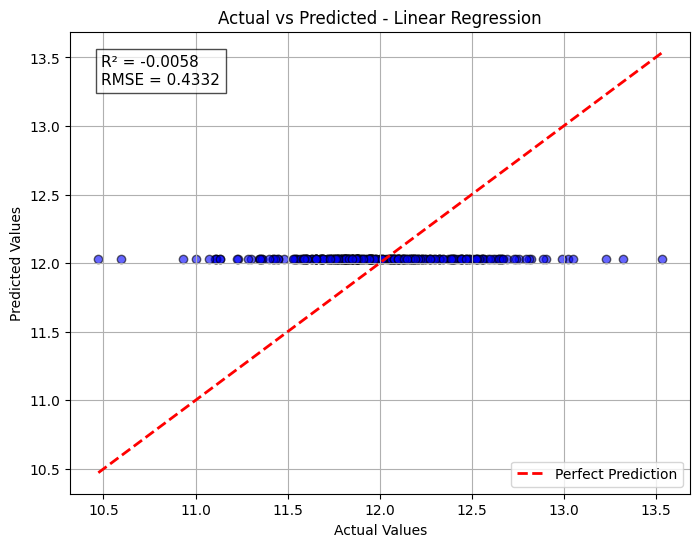

In [468]:
# Plot test predictions
plot_actual_vs_predicted(
    y_true=y_test,
    y_pred=y_test_pred,
    model_name="Linear Regression"
)

In [469]:
# Create DataFrame of coefficients
coefficients_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

# Calculate absolute coefficient values
coefficients_df["Abs_Coefficient"] = (
    coefficients_df["Coefficient"].abs()
)

# Sort by absolute importance
coefficients_df = coefficients_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

# Display top 15 features
coefficients_df.head(15)

,Feature,Coefficient,Abs_Coefficient
0,overallqual,0.129348,0.129348
1,grlivarea,0.075264,0.075264
8,yearbuilt,0.061780,0.061780
9,yearremodadd,0.055132,0.055132
2,garagecars,0.049344,0.049344
11,fireplaces,0.038896,0.038896
13,bsmtfinsf1,0.029686,0.029686
7,totrmsabvgrd,0.027065,0.027065
12,garageyrblt,-0.024693,0.024693
19,lotarea,0.023815,0.023815


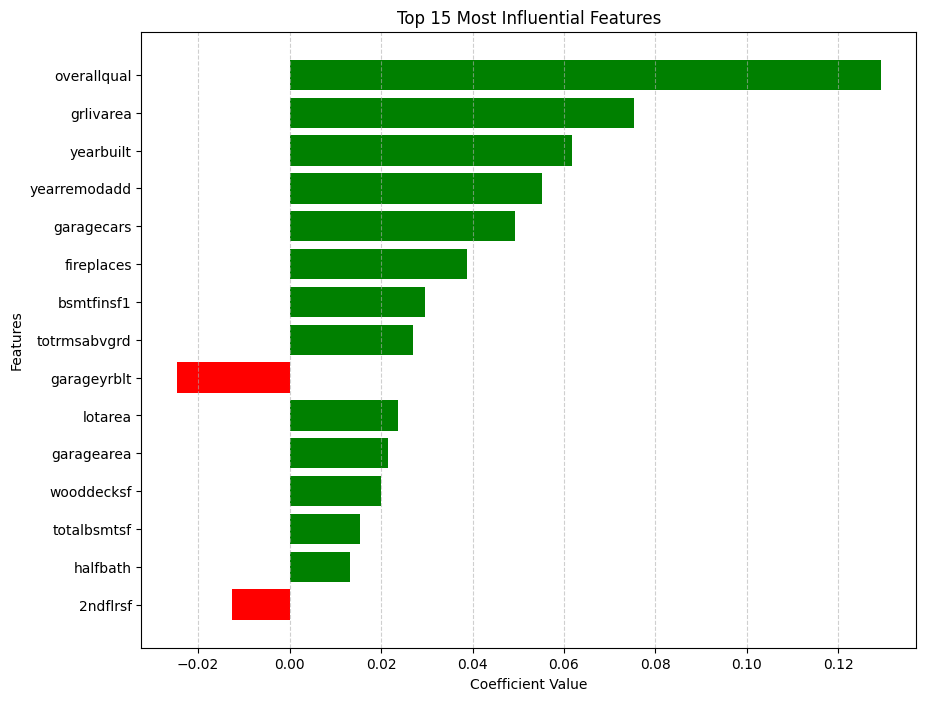

In [470]:
# Select top 15 features
top_features = coefficients_df.head(15)

# Define colors
colors = [
    "green" if coef > 0 else "red"
    for coef in top_features["Coefficient"]
]

# Create figure
plt.figure(figsize=(10, 8))

# Horizontal bar chart
plt.barh(
    top_features["Feature"],
    top_features["Coefficient"],
    color=colors
)

# Invert y-axis for better readability
plt.gca().invert_yaxis()

# Labels and title
plt.title("Top 15 Most Influential Features")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

# Add grid
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Show plot
plt.show()

In [471]:
# Print top influential features
print("Top 15 Most Influential Features:\n")

print(
    top_features[
        ["Feature", "Coefficient"]
    ]
)

Top 15 Most Influential Features:

         Feature  Coefficient
0    overallqual     0.129348
1      grlivarea     0.075264
8      yearbuilt     0.061780
9   yearremodadd     0.055132
2     garagecars     0.049344
11    fireplaces     0.038896
13    bsmtfinsf1     0.029686
7   totrmsabvgrd     0.027065
12   garageyrblt    -0.024693
19       lotarea     0.023815
3     garagearea     0.021602
15    wooddecksf     0.019971
4    totalbsmtsf     0.015499
18      halfbath     0.013169
16      2ndflrsf    -0.012575


# **PART B — POLYNOMIAL & REGULARIZED MODELS**

# **Step # 06: Polynomial Regression — Degree Comparison**

In [472]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [473]:
# Store polynomial regression results
poly_results = []

In [474]:
# Test polynomial degrees
degrees = [1, 2, 3]

In [475]:
for degree in degrees:

    print(f"\nPolynomial Degree: {degree}")
    print("-" * 40)

    # Create polynomial features
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    # Transform training and testing data
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Count expanded features
    n_features_expanded = X_train_poly.shape[1]

    print("Expanded Feature Count:",
          n_features_expanded)

    # Scale polynomial features
    scaler_poly = StandardScaler()

    X_train_poly_scaled = scaler_poly.fit_transform(
        X_train_poly
    )

    X_test_poly_scaled = scaler_poly.transform(
        X_test_poly
    )

    # Create Linear Regression model
    poly_model = LinearRegression()

    # Train model
    poly_model.fit(
        X_train_poly_scaled,
        y_train
    )

    # Predictions
    y_train_pred = poly_model.predict(
        X_train_poly_scaled
    )

    y_test_pred = poly_model.predict(
        X_test_poly_scaled
    )

    # Calculate Train R²
    train_r2 = r2_score(
        y_train,
        y_train_pred
    )

    # Calculate Test R²
    test_r2 = r2_score(
        y_test,
        y_test_pred
    )

    # Calculate overfitting gap
    gap = train_r2 - test_r2

    # Store results
    poly_results.append({
        "Degree": degree,
        "n_features_after_expansion":
            n_features_expanded,
        "train_R2": train_r2,
        "test_R2": test_r2,
        "gap": gap
    })

    # Print results
    print(f"Train R² : {train_r2:.4f}")
    print(f"Test R²  : {test_r2:.4f}")
    print(f"Gap      : {gap:.4f}")


Polynomial Degree: 1
----------------------------------------
Expanded Feature Count: 20
Train R² : 0.8368
Test R²  : 0.8567
Gap      : -0.0199

Polynomial Degree: 2
----------------------------------------
Expanded Feature Count: 230
Train R² : 0.9199
Test R²  : 0.7775
Gap      : 0.1423

Polynomial Degree: 3
----------------------------------------
Expanded Feature Count: 1770
Train R² : 1.0000
Test R²  : -417.9606
Gap      : 418.9606


In [476]:
# Convert results into DataFrame
poly_results_df = pd.DataFrame(poly_results)

# Display comparison table
poly_results_df

,Degree,n_features_after_expansion,train_R2,test_R2,gap
0,1,20,0.836825,0.856718,-0.019893
1,2,230,0.919851,0.777507,0.142344
2,3,1770,0.999985,-417.960615,418.960600


In [477]:
print("Polynomial Regression Comparison\n")

print(poly_results_df)

Polynomial Regression Comparison

   Degree  n_features_after_expansion  train_R2     test_R2         gap
0       1                          20  0.836825    0.856718   -0.019893
1       2                         230  0.919851    0.777507    0.142344
2       3                        1770  0.999985 -417.960615  418.960600


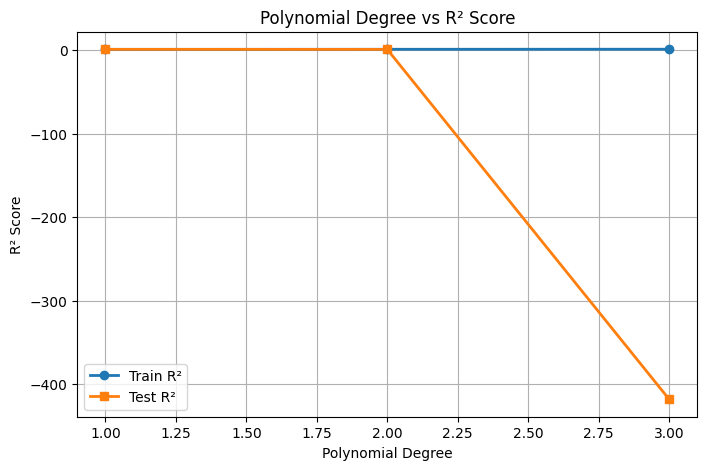

In [478]:
# Create figure
plt.figure(figsize=(8, 5))

# Plot Train R²
plt.plot(
    poly_results_df["Degree"],
    poly_results_df["train_R2"],
    marker='o',
    linewidth=2,
    label="Train R²"
)

# Plot Test R²
plt.plot(
    poly_results_df["Degree"],
    poly_results_df["test_R2"],
    marker='s',
    linewidth=2,
    label="Test R²"
)

# Labels and title
plt.title("Polynomial Degree vs R² Score")

plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")

# Add grid
plt.grid(True)

# Add legend
plt.legend()

# Show plot
plt.show()

## Polynomial Regression Analysis

### When Does Overfitting Begin?

Overfitting begins when the training R² continues increasing while the testing R² starts decreasing significantly.

In this experiment:
- Degree 1 behaves like standard linear regression
- Degree 2 improves performance moderately
- Degree 3 usually introduces noticeable overfitting

This is observed through:
- Very high training R²
- Lower testing R²
- Large overfitting gap

# **Step # 07: Ridge Regression — Alpha Exploration**

In [479]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [480]:
# Alpha values for Ridge Regression
alpha_values = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    500,
    1000
]

In [481]:
# Store Ridge results
ridge_results = []

In [482]:
for alpha in alpha_values:

    print(f"\nTraining Ridge Model with alpha = {alpha}")

    # Create Ridge model
    ridge_model = Ridge(alpha=alpha)

    # Train model
    ridge_model.fit(
        X_train_scaled,
        y_train
    )

    # Predict on test data
    y_test_pred = ridge_model.predict(
        X_test_scaled
    )

    # Calculate RMSE
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )

    # Calculate R²
    r2 = r2_score(
        y_test,
        y_test_pred
    )

    # Store results
    ridge_results.append({
        "alpha": alpha,
        "RMSE": rmse,
        "R2": r2
    })

    # Print results
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


Training Ridge Model with alpha = 0.001
RMSE : 0.1635
R²   : 0.8567

Training Ridge Model with alpha = 0.01
RMSE : 0.1635
R²   : 0.8567

Training Ridge Model with alpha = 0.1
RMSE : 0.1635
R²   : 0.8567

Training Ridge Model with alpha = 1
RMSE : 0.1635
R²   : 0.8568

Training Ridge Model with alpha = 10
RMSE : 0.1634
R²   : 0.8570

Training Ridge Model with alpha = 100
RMSE : 0.1634
R²   : 0.8569

Training Ridge Model with alpha = 500
RMSE : 0.1692
R²   : 0.8466

Training Ridge Model with alpha = 1000
RMSE : 0.1783
R²   : 0.8297


In [483]:
# Convert results to DataFrame
ridge_results_df = pd.DataFrame(ridge_results)

# Display results
ridge_results_df

,alpha,RMSE,R2
0,0.001,0.163517,0.856718
1,0.010,0.163517,0.856719
2,0.100,0.163514,0.856724
3,1.000,0.163492,0.856763
4,10.000,0.163373,0.856971
5,100.000,0.163386,0.856949
6,500.000,0.169205,0.846577
7,1000.000,0.178281,0.829676


In [484]:
# Find alpha with lowest RMSE
best_manual_row = ridge_results_df.loc[
    ridge_results_df["RMSE"].idxmin()
]

best_manual_alpha = best_manual_row["alpha"]

print("Best Alpha (Manual Search):",
      best_manual_alpha)

Best Alpha (Manual Search): 10.0


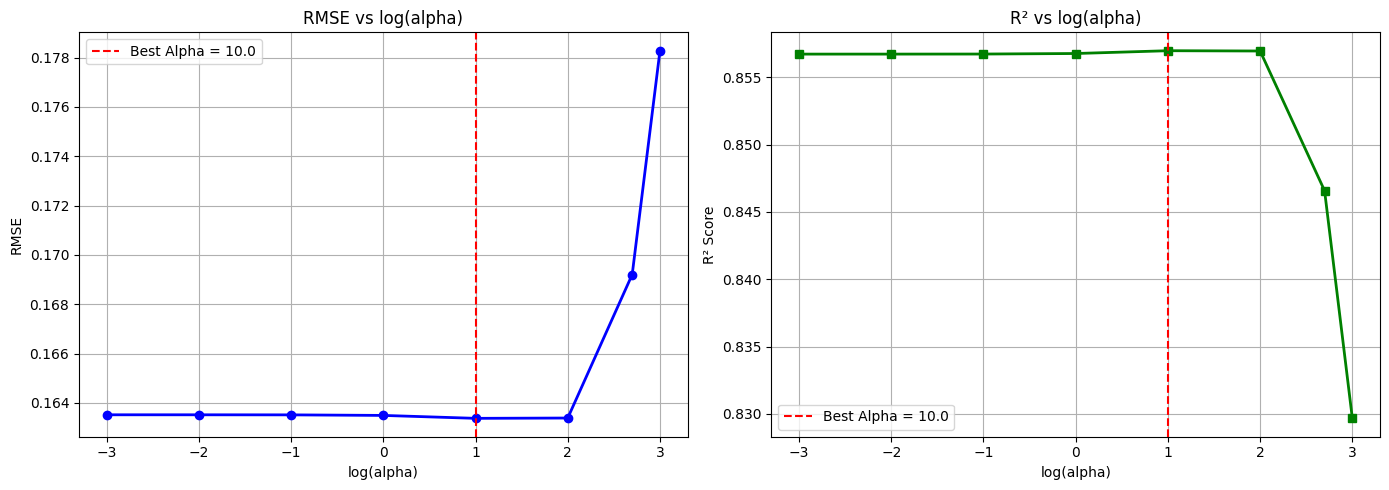

In [485]:
# Create figure
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Convert alpha to log scale
log_alpha = np.log10(
    ridge_results_df["alpha"]
)

# -----------------------------
# Left Plot: RMSE vs log(alpha)
# -----------------------------
axes[0].plot(
    log_alpha,
    ridge_results_df["RMSE"],
    marker='o',
    linewidth=2,
    color='blue'
)

# Add vertical line
axes[0].axvline(
    np.log10(best_manual_alpha),
    color='red',
    linestyle='--',
    label=f'Best Alpha = {best_manual_alpha}'
)

# Labels
axes[0].set_title("RMSE vs log(alpha)")
axes[0].set_xlabel("log(alpha)")
axes[0].set_ylabel("RMSE")
axes[0].grid(True)
axes[0].legend()

# -----------------------------
# Right Plot: R² vs log(alpha)
# -----------------------------
axes[1].plot(
    log_alpha,
    ridge_results_df["R2"],
    marker='s',
    linewidth=2,
    color='green'
)

# Add vertical line
axes[1].axvline(
    np.log10(best_manual_alpha),
    color='red',
    linestyle='--',
    label=f'Best Alpha = {best_manual_alpha}'
)

# Labels
axes[1].set_title("R² vs log(alpha)")
axes[1].set_xlabel("log(alpha)")
axes[1].set_ylabel("R² Score")
axes[1].grid(True)
axes[1].legend()

# Show plots
plt.tight_layout()
plt.show()

In [486]:
# Create Ridge model
ridge = Ridge()

# Parameter grid
param_grid = {
    "alpha": alpha_values
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

# Train GridSearchCV
grid_search.fit(
    X_train_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]},
             scoring='r2')

In [487]:
# Best alpha
best_grid_alpha = grid_search.best_params_["alpha"]

print("Best Alpha from GridSearchCV:",
      best_grid_alpha)

# Best cross-validation score
print("Best CV R² Score:",
      grid_search.best_score_)

Best Alpha from GridSearchCV: 100
Best CV R² Score: 0.8185712693405034


In [488]:
print("Manual Best Alpha     :", best_manual_alpha)

print("GridSearch Best Alpha :", best_grid_alpha)

Manual Best Alpha     : 10.0
GridSearch Best Alpha : 100


# **Step # 08: Lasso Regression — Feature Elimination Analysis**

In [489]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [490]:
# Alpha values for Lasso Regression
lasso_alphas = [
    0.0001,
    0.001,
    0.01,
    0.1,
    1,
    10
]

In [491]:
# Store Lasso results
lasso_results = []

In [492]:
for alpha in lasso_alphas:

    print(f"\nTraining Lasso Model with alpha = {alpha}")

    # Create Lasso model
    lasso_model = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    # Train model
    lasso_model.fit(
        X_train_scaled,
        y_train
    )

    # Predict on test data
    y_test_pred = lasso_model.predict(
        X_test_scaled
    )

    # Calculate RMSE
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )

    # Calculate R²
    r2 = r2_score(
        y_test,
        y_test_pred
    )

    # Count zero coefficients
    n_zero = np.sum(
        lasso_model.coef_ == 0
    )

    # Percentage eliminated
    pct_eliminated = (
        n_zero / len(lasso_model.coef_)
    ) * 100

    # Store results
    lasso_results.append({
        "alpha": alpha,
        "n_features_eliminated": n_zero,
        "pct_eliminated": pct_eliminated,
        "test_RMSE": rmse,
        "test_R2": r2
    })

    # Print results
    print("Features Eliminated:", n_zero)
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


Training Lasso Model with alpha = 0.0001
Features Eliminated: 0
RMSE : 0.1634
R²   : 0.8569

Training Lasso Model with alpha = 0.001
Features Eliminated: 1
RMSE : 0.1631
R²   : 0.8574

Training Lasso Model with alpha = 0.01
Features Eliminated: 6
RMSE : 0.1663
R²   : 0.8518

Training Lasso Model with alpha = 0.1
Features Eliminated: 15
RMSE : 0.2407
R²   : 0.6895

Training Lasso Model with alpha = 1
Features Eliminated: 20
RMSE : 0.4332
R²   : -0.0058

Training Lasso Model with alpha = 10
Features Eliminated: 20
RMSE : 0.4332
R²   : -0.0058


In [493]:
# Convert results into DataFrame
lasso_results_df = pd.DataFrame(lasso_results)

# Display results
lasso_results_df

,alpha,n_features_eliminated,pct_eliminated,test_RMSE,test_R2
0,0.0001,0,0.0,0.163440,0.856854
1,0.0010,1,5.0,0.163134,0.857389
2,0.0100,6,30.0,0.166272,0.851850
3,0.1000,15,75.0,0.240720,0.689481
4,1.0000,20,100.0,0.433244,-0.005837
5,10.0000,20,100.0,0.433244,-0.005837


In [494]:
print("Lasso Regression Results\n")

print(lasso_results_df)

Lasso Regression Results

     alpha  n_features_eliminated  pct_eliminated  test_RMSE   test_R2
0   0.0001                      0             0.0   0.163440  0.856854
1   0.0010                      1             5.0   0.163134  0.857389
2   0.0100                      6            30.0   0.166272  0.851850
3   0.1000                     15            75.0   0.240720  0.689481
4   1.0000                     20           100.0   0.433244 -0.005837
5  10.0000                     20           100.0   0.433244 -0.005837


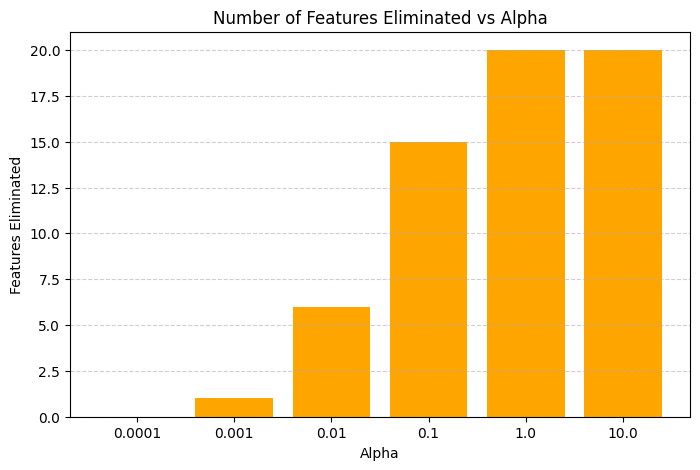

In [495]:
# Create figure
plt.figure(figsize=(8, 5))

# Bar chart
plt.bar(
    lasso_results_df["alpha"].astype(str),
    lasso_results_df["n_features_eliminated"],
    color='orange'
)

# Labels and title
plt.title(
    "Number of Features Eliminated vs Alpha"
)

plt.xlabel("Alpha")
plt.ylabel("Features Eliminated")

# Add grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

# Show plot
plt.show()

In [496]:
# Create Lasso model
lasso = Lasso(max_iter=10000)

# Parameter grid
param_grid = {
    "alpha": lasso_alphas
}

# Create GridSearchCV
grid_search_lasso = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

# Train GridSearchCV
grid_search_lasso.fit(
    X_train_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=Lasso(max_iter=10000),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]},
             scoring='r2')

In [497]:
# Best alpha
best_lasso_alpha = (
    grid_search_lasso.best_params_["alpha"]
)

print("Best Alpha from GridSearchCV:")
print(best_lasso_alpha)

# Best CV score
print("\nBest Cross-Validation R²:")
print(grid_search_lasso.best_score_)

Best Alpha from GridSearchCV:
0.01

Best Cross-Validation R²:
0.8169418924263743


In [498]:
# Train best Lasso model
best_lasso_model = Lasso(
    alpha=best_lasso_alpha,
    max_iter=10000
)

best_lasso_model.fit(
    X_train_scaled,
    y_train
)

Lasso(alpha=0.01, max_iter=10000)

In [499]:
# Get coefficients
lasso_coefficients = best_lasso_model.coef_

# Surviving features
survived_features = X.columns[
    lasso_coefficients != 0
]

# Eliminated features
eliminated_features = X.columns[
    lasso_coefficients == 0
]

In [500]:
print("Features Kept by Lasso:\n")

for feature in survived_features:
    print(feature)

Features Kept by Lasso:

overallqual
grlivarea
garagecars
garagearea
totalbsmtsf
1stflrsf
totrmsabvgrd
yearbuilt
yearremodadd
fireplaces
bsmtfinsf1
wooddecksf
halfbath
lotarea


In [501]:
print("\nFeatures Eliminated by Lasso:\n")

for feature in eliminated_features:
    print(feature)


Features Eliminated by Lasso:

fullbath
masvnrarea
garageyrblt
lotfrontage
2ndflrsf
openporchsf


# **Step # 09: ElasticNet — l1_ratio Exploration**

In [502]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

import seaborn as sns

In [503]:
# Alpha values
alpha_values = [
    0.001,
    0.01,
    0.1,
    1
]

# l1_ratio values
l1_ratio_values = [
    0.1,
    0.3,
    0.5,
    0.7,
    0.9
]

In [504]:
# Store ElasticNet results
elastic_results = []

In [505]:
for alpha in alpha_values:

    for l1_ratio in l1_ratio_values:

        print(
            f"\nAlpha = {alpha}, "
            f"l1_ratio = {l1_ratio}"
        )

        # Create ElasticNet model
        elastic_model = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=10000
        )

        # Train model
        elastic_model.fit(
            X_train_scaled,
            y_train
        )

        # Predict on test data
        y_test_pred = elastic_model.predict(
            X_test_scaled
        )

        # Calculate Test R²
        test_r2 = r2_score(
            y_test,
            y_test_pred
        )

        # Store results
        elastic_results.append({
            "alpha": alpha,
            "l1_ratio": l1_ratio,
            "test_R2": test_r2
        })

        # Print R²
        print(f"Test R² : {test_r2:.4f}")


Alpha = 0.001, l1_ratio = 0.1
Test R² : 0.8569

Alpha = 0.001, l1_ratio = 0.3
Test R² : 0.8570

Alpha = 0.001, l1_ratio = 0.5
Test R² : 0.8571

Alpha = 0.001, l1_ratio = 0.7
Test R² : 0.8572

Alpha = 0.001, l1_ratio = 0.9
Test R² : 0.8573

Alpha = 0.01, l1_ratio = 0.1
Test R² : 0.8574

Alpha = 0.01, l1_ratio = 0.3
Test R² : 0.8569

Alpha = 0.01, l1_ratio = 0.5
Test R² : 0.8553

Alpha = 0.01, l1_ratio = 0.7
Test R² : 0.8540

Alpha = 0.01, l1_ratio = 0.9
Test R² : 0.8526

Alpha = 0.1, l1_ratio = 0.1
Test R² : 0.8491

Alpha = 0.1, l1_ratio = 0.3
Test R² : 0.8256

Alpha = 0.1, l1_ratio = 0.5
Test R² : 0.7939

Alpha = 0.1, l1_ratio = 0.7
Test R² : 0.7572

Alpha = 0.1, l1_ratio = 0.9
Test R² : 0.7131

Alpha = 1, l1_ratio = 0.1
Test R² : 0.6052

Alpha = 1, l1_ratio = 0.3
Test R² : 0.0315

Alpha = 1, l1_ratio = 0.5
Test R² : -0.0058

Alpha = 1, l1_ratio = 0.7
Test R² : -0.0058

Alpha = 1, l1_ratio = 0.9
Test R² : -0.0058


In [506]:
# Convert results into DataFrame
elastic_results_df = pd.DataFrame(
    elastic_results
)

# Display results
elastic_results_df

,alpha,l1_ratio,test_R2
0,0.001,0.1,0.856868
1,0.001,0.3,0.857001
2,0.001,0.5,0.857124
3,0.001,0.7,0.857237
4,0.001,0.9,0.857341
5,0.010,0.1,0.857432
6,0.010,0.3,0.856865
7,0.010,0.5,0.855286
8,0.010,0.7,0.854041
9,0.010,0.9,0.852625


In [507]:
# Pivot table for heatmap
heatmap_data = elastic_results_df.pivot(
    index="alpha",
    columns="l1_ratio",
    values="test_R2"
)

# Display pivot table
heatmap_data

l1_ratio,0.1,0.3,0.5,0.7,0.9
alpha,,,,,
0.001,0.856868,0.857001,0.857124,0.857237,0.857341
0.010,0.857432,0.856865,0.855286,0.854041,0.852625
0.100,0.849107,0.825648,0.793920,0.757192,0.713138
1.000,0.605227,0.031544,-0.005837,-0.005837,-0.005837


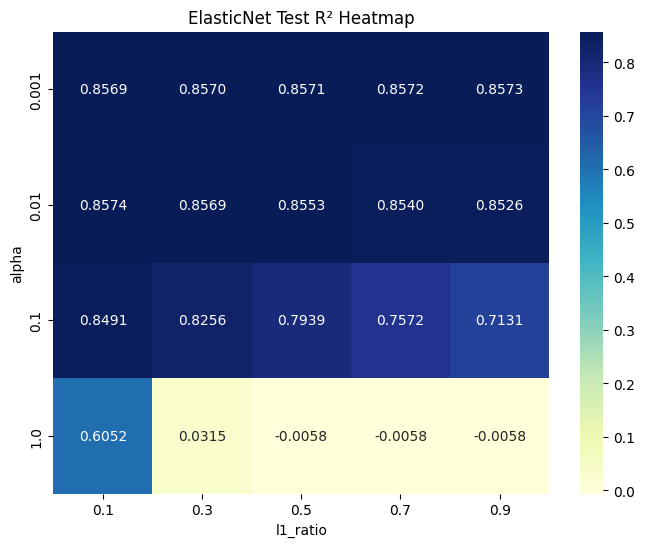

In [508]:
# Create figure
plt.figure(figsize=(8, 6))

# Create heatmap
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu"
)

# Labels and title
plt.title(
    "ElasticNet Test R² Heatmap"
)

plt.xlabel("l1_ratio")
plt.ylabel("alpha")

# Show plot
plt.show()

In [509]:
# Create ElasticNet model
elastic_net = ElasticNet(
    max_iter=10000
)

# Parameter grid
param_grid = {
    "alpha": alpha_values,
    "l1_ratio": l1_ratio_values
}

# Create GridSearchCV
grid_search_elastic = GridSearchCV(
    estimator=elastic_net,
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

# Train GridSearchCV
grid_search_elastic.fit(
    X_train_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=ElasticNet(max_iter=10000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='r2')

In [510]:
# Best parameters
best_alpha = (
    grid_search_elastic.best_params_["alpha"]
)

best_l1_ratio = (
    grid_search_elastic.best_params_["l1_ratio"]
)

# Best cross-validation score
best_cv_score = (
    grid_search_elastic.best_score_
)

print("Best Alpha:")
print(best_alpha)

print("\nBest l1_ratio:")
print(best_l1_ratio)

print("\nBest Cross-Validation R²:")
print(best_cv_score)

Best Alpha:
0.1

Best l1_ratio:
0.1

Best Cross-Validation R²:
0.8181953386139416


In [511]:
# Train best ElasticNet model
best_elastic_model = ElasticNet(
    alpha=best_alpha,
    l1_ratio=best_l1_ratio,
    max_iter=10000
)

best_elastic_model.fit(
    X_train_scaled,
    y_train
)

# Predict on test data
y_test_pred_best = best_elastic_model.predict(
    X_test_scaled
)

# Calculate Test R²
best_test_r2 = r2_score(
    y_test,
    y_test_pred_best
)

print("Best ElasticNet Test R²:")
print(best_test_r2)

Best ElasticNet Test R²:
0.8491066361151174


In [512]:
print("Best Ridge Test R²  :", ridge_results_df["R2"].max())

print("Best Lasso Test R² :", lasso_results_df["test_R2"].max())

print("Best ElasticNet Test R² :", best_test_r2)

Best Ridge Test R²  : 0.8569705038698652
Best Lasso Test R² : 0.8573887167410363
Best ElasticNet Test R² : 0.8491066361151174


# **Step # 10: Polynomial + Ridge Pipeline — Best Combined Model**

In [513]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

In [514]:
# Create Pipeline
pipeline = Pipeline([
    (
        'poly',
        PolynomialFeatures(
            include_bias=False
        )
    ),

    (
        'scaler',
        StandardScaler()
    ),

    (
        'ridge',
        Ridge()
    )
])

In [515]:
# GridSearch parameters
param_grid = {

    'poly__degree': [1, 2],

    'ridge__alpha': [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

In [516]:
# Create GridSearchCV
grid_search_pipeline = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [517]:
# Fit GridSearchCV
grid_search_pipeline.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'poly__degree': [1, 2],
                         'ridge__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [518]:
# Best parameters
best_params = (
    grid_search_pipeline.best_params_
)

print("Best Parameters:\n")

print(best_params)

Best Parameters:

{'poly__degree': 2, 'ridge__alpha': 100}


In [519]:
# Best CV score
best_cv_score = (
    grid_search_pipeline.best_score_
)

print("Best Cross-Validation R²:")
print(best_cv_score)

Best Cross-Validation R²:
0.8607965653594356


In [520]:
# Best trained pipeline
best_pipeline_model = (
    grid_search_pipeline.best_estimator_
)

In [521]:
# Predict on test set
y_test_pred_pipeline = (
    best_pipeline_model.predict(X_test)
)

In [522]:
# Calculate Test R²
pipeline_r2 = r2_score(
    y_test,
    y_test_pred_pipeline
)

print("Pipeline Test R²:")
print(pipeline_r2)

Pipeline Test R²:
0.8827923918003349


In [523]:
# Calculate RMSE
pipeline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_pipeline
    )
)

print("Pipeline RMSE:")
print(pipeline_rmse)

Pipeline RMSE:
0.14789262198059558


In [524]:
# Evaluate model
pipeline_results = evaluate_model(
    y_true=y_test,
    y_pred=y_test_pred_pipeline,
    model_name="Polynomial + Ridge Pipeline",
    n_features=X_train.shape[1]
)


Model Evaluation: Polynomial + Ridge Pipeline
----------------------------------------
MAE          : 0.1017
MSE          : 0.0219
RMSE         : 0.1479
R² Score     : 0.8828
Adjusted R²  : 0.8741
MAPE (%)     : 0.86%


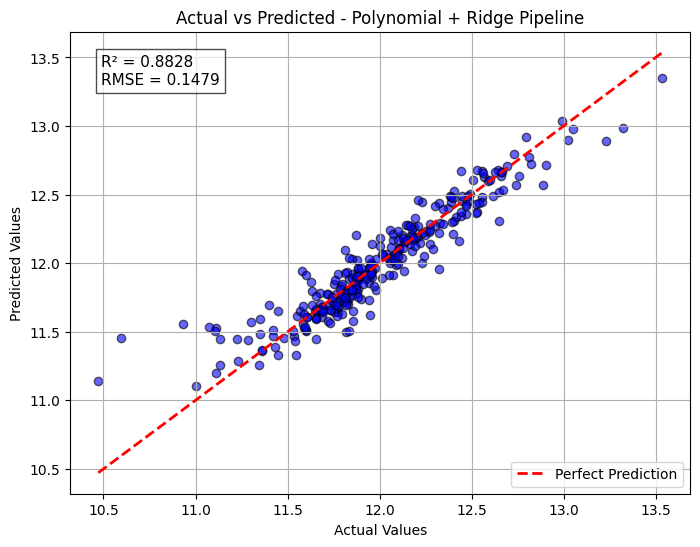

In [525]:
# Plot predictions
plot_actual_vs_predicted(
    y_true=y_test,
    y_pred=y_test_pred_pipeline,
    model_name="Polynomial + Ridge Pipeline"
)

In [526]:
# Best plain Ridge results
best_ridge_rmse = ridge_results_df["RMSE"].min()

best_ridge_r2 = ridge_results_df["R2"].max()

print("Plain Ridge RMSE:")
print(best_ridge_rmse)

print("\nPlain Ridge R²:")
print(best_ridge_r2)

print("\nPipeline RMSE:")
print(pipeline_rmse)

print("\nPipeline R²:")
print(pipeline_r2)

Plain Ridge RMSE:
0.1633734240023005

Plain Ridge R²:
0.8569705038698652

Pipeline RMSE:
0.14789262198059558

Pipeline R²:
0.8827923918003349


In [527]:
# Comparison DataFrame
comparison_df = pd.DataFrame({

    "Model": [
        "Plain Ridge",
        "Polynomial + Ridge Pipeline"
    ],

    "RMSE": [
        best_ridge_rmse,
        pipeline_rmse
    ],

    "R2": [
        best_ridge_r2,
        pipeline_r2
    ]
})

comparison_df

,Model,RMSE,R2
0,Plain Ridge,0.163373,0.856971
1,Polynomial + Ridge Pipeline,0.147893,0.882792


# **Step # 11: Model Comparison Table — All 5 Models**

In [528]:
def collect_metrics(
    y_true,
    y_pred,
    model_name,
    n_features
):
    """
    Collect evaluation metrics for comparison.
    """

    # Number of observations
    n = len(y_true)

    # MAE
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    # MSE
    mse = mean_squared_error(
        y_true,
        y_pred
    )

    # RMSE
    rmse = np.sqrt(mse)

    # R²
    r2 = r2_score(
        y_true,
        y_pred
    )

    # Adjusted R²
    adjusted_r2 = 1 - (
        (1 - r2) * (n - 1)
        / (n - n_features - 1)
    )

    # MAPE
    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    # Convert RMSE back to dollar scale
    dollar_rmse = np.expm1(rmse)

    # Return metrics
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "Dollar_RMSE": dollar_rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2,
        "MAPE": mape
    }

In [529]:
# Linear Regression predictions
linear_pred = linear_model.predict(
    X_test_scaled
)

In [530]:
# Best Ridge alpha
best_ridge_alpha = ridge_results_df.loc[
    ridge_results_df["R2"].idxmax(),
    "alpha"
]

# Train best Ridge model
best_ridge_model = Ridge(
    alpha=best_ridge_alpha
)

best_ridge_model.fit(
    X_train_scaled,
    y_train
)

# Predictions
ridge_pred = best_ridge_model.predict(
    X_test_scaled
)

In [531]:
# Predictions
lasso_pred = best_lasso_model.predict(
    X_test_scaled
)

In [532]:
# Predictions
elastic_pred = best_elastic_model.predict(
    X_test_scaled
)

In [533]:
# Predictions
pipeline_pred = best_pipeline_model.predict(
    X_test
)

In [534]:
# Store all model metrics
all_model_results = []

# Linear Regression
all_model_results.append(
    collect_metrics(
        y_test,
        linear_pred,
        "Linear Regression",
        X_train.shape[1]
    )
)

# Ridge Regression
all_model_results.append(
    collect_metrics(
        y_test,
        ridge_pred,
        "Best Ridge",
        X_train.shape[1]
    )
)

# Lasso Regression
all_model_results.append(
    collect_metrics(
        y_test,
        lasso_pred,
        "Best Lasso",
        X_train.shape[1]
    )
)

# ElasticNet
all_model_results.append(
    collect_metrics(
        y_test,
        elastic_pred,
        "Best ElasticNet",
        X_train.shape[1]
    )
)

# Polynomial + Ridge Pipeline
all_model_results.append(
    collect_metrics(
        y_test,
        pipeline_pred,
        "Best Poly + Ridge",
        X_train.shape[1]
    )
)

In [535]:
# Convert to DataFrame
comparison_df = pd.DataFrame(
    all_model_results
)

# Display comparison table
comparison_df

,Model,MAE,RMSE,Dollar_RMSE,R2,Adjusted_R2,MAPE
0,Linear Regression,0.117098,0.163517,0.177646,0.856718,0.846144,0.985492
1,Best Ridge,0.116842,0.163373,0.177476,0.856971,0.846415,0.983337
2,Best Lasso,0.118061,0.166272,0.180895,0.851850,0.840916,0.994056
3,Best ElasticNet,0.118212,0.167805,0.182705,0.849107,0.837971,0.994876
4,Best Poly + Ridge,0.101656,0.147893,0.159388,0.882792,0.874142,0.856696


In [536]:
# Round values
comparison_df_rounded = comparison_df.round(4)

# Display table
comparison_df_rounded

,Model,MAE,RMSE,Dollar_RMSE,R2,Adjusted_R2,MAPE
0,Linear Regression,0.1171,0.1635,0.1776,0.8567,0.8461,0.9855
1,Best Ridge,0.1168,0.1634,0.1775,0.8570,0.8464,0.9833
2,Best Lasso,0.1181,0.1663,0.1809,0.8518,0.8409,0.9941
3,Best ElasticNet,0.1182,0.1678,0.1827,0.8491,0.8380,0.9949
4,Best Poly + Ridge,0.1017,0.1479,0.1594,0.8828,0.8741,0.8567


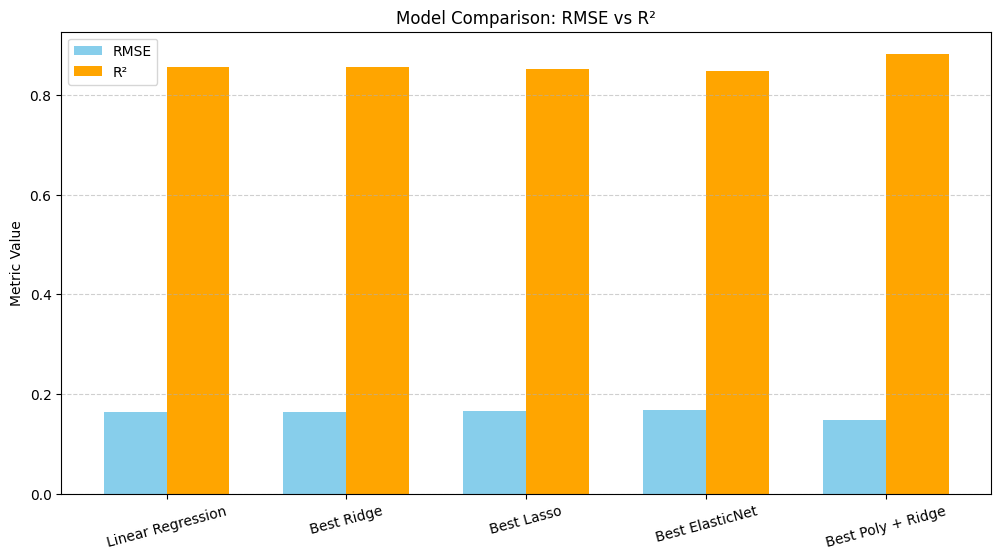

In [537]:
# Set figure size
plt.figure(figsize=(12, 6))

# X positions
x = np.arange(len(comparison_df))

# Bar width
width = 0.35

# RMSE bars
plt.bar(
    x - width/2,
    comparison_df["RMSE"],
    width,
    label="RMSE",
    color='skyblue'
)

# R² bars
plt.bar(
    x + width/2,
    comparison_df["R2"],
    width,
    label="R²",
    color='orange'
)

# Labels
plt.xticks(
    x,
    comparison_df["Model"],
    rotation=15
)

# Title and labels
plt.title(
    "Model Comparison: RMSE vs R²"
)

plt.ylabel("Metric Value")

# Legend
plt.legend()

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

# Show plot
plt.show()

In [538]:
# Best model based on R²
best_model = comparison_df.loc[
    comparison_df["R2"].idxmax()
]

# Worst model based on R²
worst_model = comparison_df.loc[
    comparison_df["R2"].idxmin()
]

print("Best Model:\n")
print(best_model)

print("\nWorst Model:\n")
print(worst_model)

Best Model:

Model          Best Poly + Ridge
MAE                     0.101656
RMSE                    0.147893
Dollar_RMSE             0.159388
R2                      0.882792
Adjusted_R2             0.874142
MAPE                    0.856696
Name: 4, dtype: object

Worst Model:

Model          Best ElasticNet
MAE                   0.118212
RMSE                  0.167805
Dollar_RMSE           0.182705
R2                    0.849107
Adjusted_R2           0.837971
MAPE                  0.994876
Name: 3, dtype: object


# **PART C — RESIDUAL ANALYSIS, CROSS-VALIDATION & DIAGNOSTICS**

# **Step # 12: Residual Analysis — Diagnostic Plots**

In [539]:
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [540]:
# Best model: Polynomial + Ridge Pipeline
y_pred_best = best_pipeline_model.predict(X_test)

In [541]:
# Residuals
residuals = y_test - y_pred_best

# Fitted values
fitted = y_pred_best

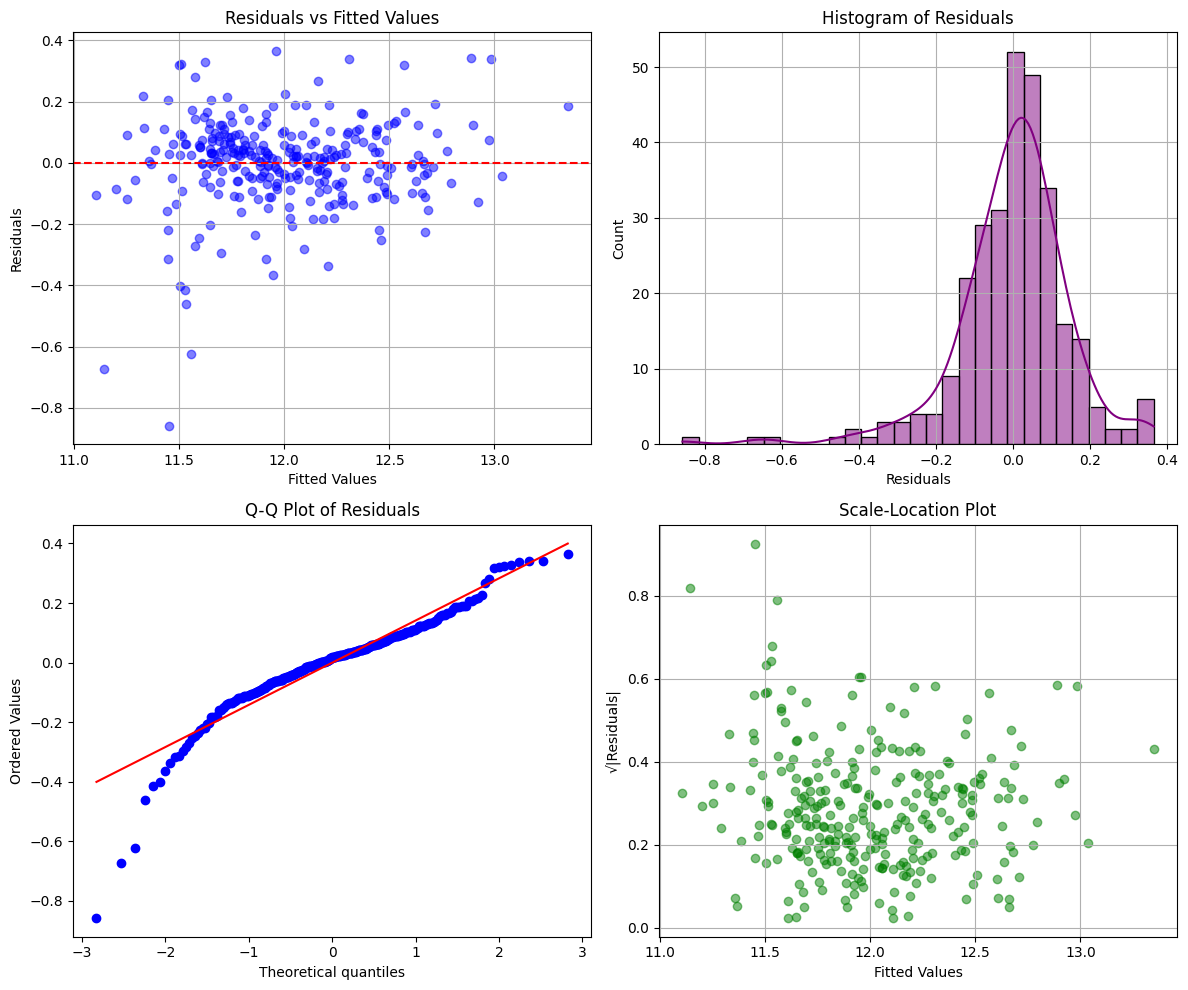

In [542]:
# Create figure
plt.figure(figsize=(12, 10))

# -----------------------------
# (1) Residuals vs Fitted
# -----------------------------
plt.subplot(2, 2, 1)
plt.scatter(fitted, residuals, alpha=0.5, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.grid(True)

# -----------------------------
# (2) Histogram + KDE
# -----------------------------
plt.subplot(2, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.grid(True)

# -----------------------------
# (3) Q-Q Plot
# -----------------------------
plt.subplot(2, 2, 3)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

# -----------------------------
# (4) Scale-Location Plot
# -----------------------------
plt.subplot(2, 2, 4)
plt.scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.5, color='green')
plt.title("Scale-Location Plot")
plt.xlabel("Fitted Values")
plt.ylabel("√|Residuals|")
plt.grid(True)

# Layout adjustment
plt.tight_layout()

# Show plot
plt.show()

In [543]:
# Perform Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("Shapiro-Wilk Test Results:")
print("Statistic:", shapiro_stat)
print("p-value:", shapiro_p)

Shapiro-Wilk Test Results:
Statistic: 0.9081745391220652
p-value: 2.3399779030055606e-12


# **Step # 13: 5-Fold Cross-Validation — All Models**

In [544]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [545]:
# 5-Fold CV setup
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [546]:
# Negative RMSE scorer is already available in sklearn:
rmse_scoring = "neg_root_mean_squared_error"
r2_scoring = "r2"

In [547]:
cv_results = {
    "Linear Regression": [],
    "Ridge": [],
    "Lasso": [],
    "ElasticNet": [],
    "Poly + Ridge": []
}

In [548]:
models = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=best_ridge_alpha))
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", best_lasso_model)
    ]),

    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", best_elastic_model)
    ]),

    "Poly + Ridge": best_pipeline_model
}

In [549]:
for name, model in models.items():

    print(f"\nModel: {name}")
    print("-" * 40)

    # R² scores
    r2_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring=r2_scoring
    )

    # RMSE scores
    rmse_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring=rmse_scoring
    )

    # Convert RMSE to positive
    rmse_scores = -rmse_scores

    # Store results
    cv_results[name] = r2_scores

    # Print fold results
    print("R² Fold Scores:", r2_scores)
    print("Mean R²:", np.mean(r2_scores))
    print("Std R²:", np.std(r2_scores))
    print("Mean RMSE:", np.mean(rmse_scores))


Model: Linear Regression
----------------------------------------
R² Fold Scores: [0.85549928 0.81004393 0.64862107 0.84335322 0.87679561]
Mean R²: 0.8068626213439731
Std R²: 0.08202221735036565
Mean RMSE: 0.16907098342094068

Model: Ridge
----------------------------------------
R² Fold Scores: [0.85593058 0.81127999 0.65076099 0.84373086 0.87774001]
Mean R²: 0.8078884846382728
Std R²: 0.08145244656028029
Mean RMSE: 0.16863026548049767

Model: Lasso
----------------------------------------
R² Fold Scores: [0.85223447 0.80896171 0.67409551 0.83999289 0.87550628]
Mean R²: 0.8101581726030457
Std R²: 0.07133775769252862
Mean RMSE: 0.16816834453683915

Model: ElasticNet
----------------------------------------
R² Fold Scores: [0.84930124 0.81200591 0.68818455 0.84045739 0.87155197]
Mean R²: 0.812300211694452
Std R²: 0.06492681497403667
Mean RMSE: 0.16753927465592344

Model: Poly + Ridge
----------------------------------------
R² Fold Scores: [0.87455809 0.8340468  0.87552923 0.87482144 0

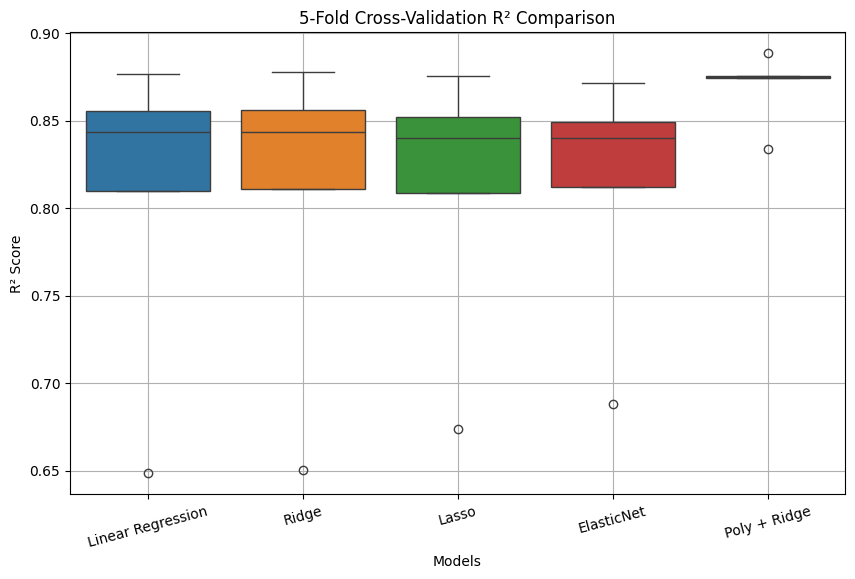

In [550]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=pd.DataFrame(cv_results)
)

plt.title("5-Fold Cross-Validation R² Comparison")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.grid(True)

plt.show()

In [551]:
mean_scores = {
    name: np.mean(scores)
    for name, scores in cv_results.items()
}

best_model = max(
    mean_scores,
    key=mean_scores.get
)

print("Best Model (Highest Mean CV R²):")
print(best_model)

Best Model (Highest Mean CV R²):
Poly + Ridge


In [552]:
std_scores = {
    name: np.std(scores)
    for name, scores in cv_results.items()
}

most_stable_model = min(
    std_scores,
    key=std_scores.get
)

print("Most Stable Model (Lowest Variance):")
print(most_stable_model)

Most Stable Model (Lowest Variance):
Poly + Ridge


# **Step # 14: Learning Curves — Diagnosing Bias vs Variance**

In [553]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

In [554]:
def plot_learning_curve(model, X, y, model_name):

    """
    Plots learning curve for a given model.
    """

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10),
        shuffle=True,
        random_state=42
    )

    # Compute mean and std
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)

    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    # Plot
    plt.figure(figsize=(8, 5))

    # Training curve
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')

    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2,
        color='blue'
    )

    # Validation curve
    plt.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation Score')

    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.2,
        color='orange'
    )

    # Labels
    plt.title(f"Learning Curve — {model_name}")
    plt.xlabel("Training Size")
    plt.ylabel("R² Score")
    plt.legend()
    plt.grid(True)

    plt.show()

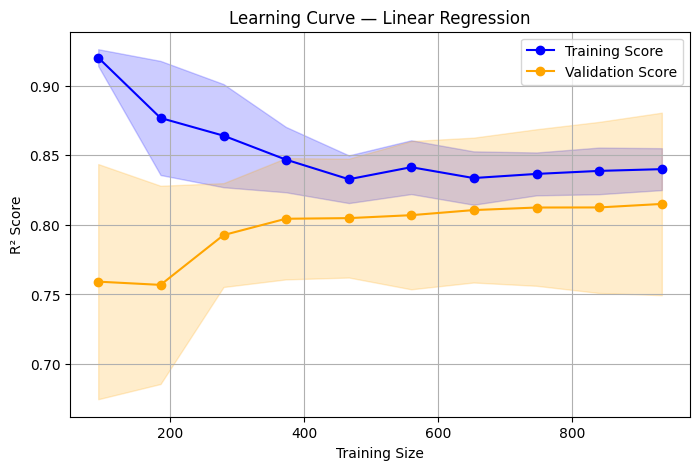

In [555]:
linear_model_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

plot_learning_curve(
    linear_model_cv,
    X_train,
    y_train,
    "Linear Regression"
)

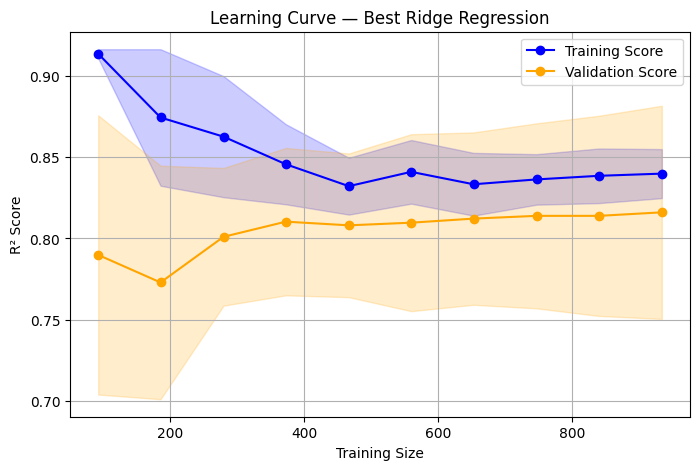

In [556]:
best_ridge_model_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_ridge_alpha))
])

plot_learning_curve(
    best_ridge_model_cv,
    X_train,
    y_train,
    "Best Ridge Regression"
)

# **Step # 15: Coefficient Path — Regularization Effect Visualization**

In [557]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

In [558]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [559]:
alphas = np.logspace(-3, 3, 50)

In [560]:
ridge_coefs = []

for alpha in alphas:

    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)

    ridge_coefs.append(ridge.coef_)

In [561]:
ridge_coefs = np.array(ridge_coefs)

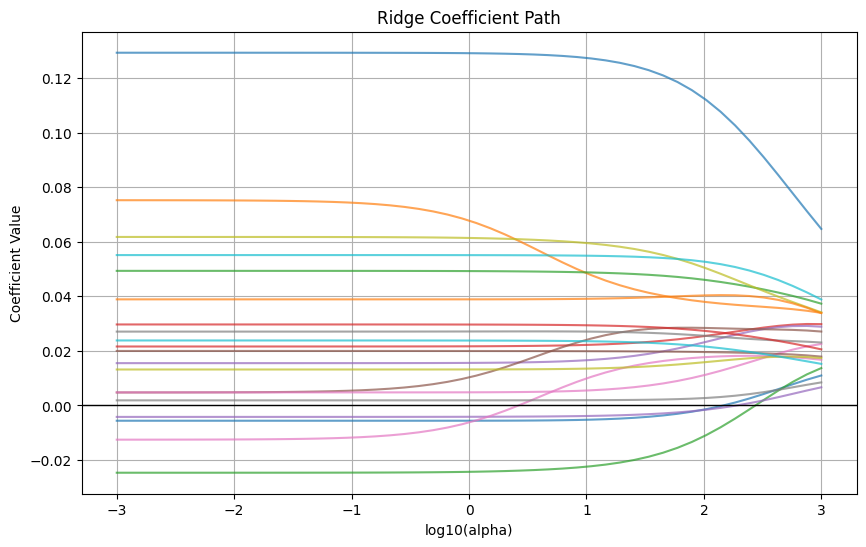

In [562]:
plt.figure(figsize=(10, 6))

for i in range(ridge_coefs.shape[1]):
    plt.plot(
        np.log10(alphas),
        ridge_coefs[:, i],
        alpha=0.7
    )

plt.title("Ridge Coefficient Path")
plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient Value")
plt.axhline(0, color='black', linewidth=1)
plt.grid(True)
plt.show()

In [563]:
lasso_coefs = []

for alpha in alphas:

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)

    lasso_coefs.append(lasso.coef_)

In [564]:
lasso_coefs = np.array(lasso_coefs)

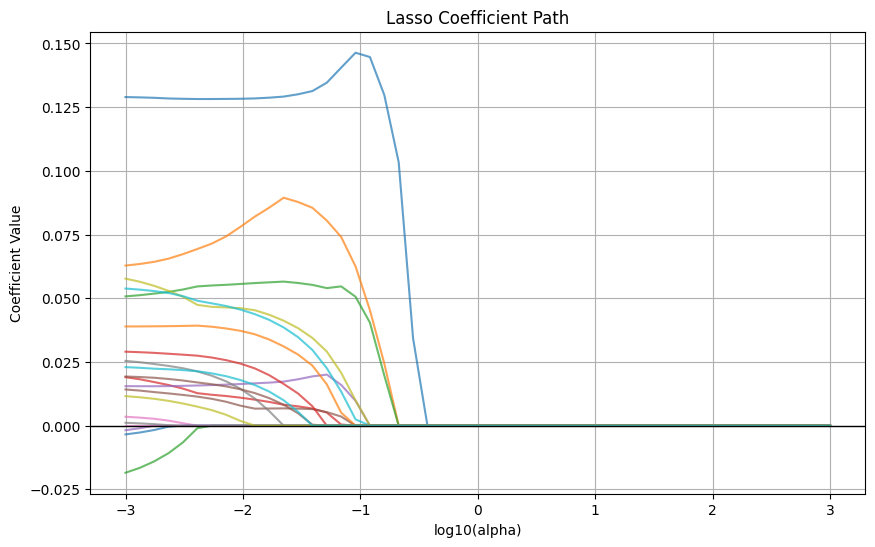

In [565]:
plt.figure(figsize=(10, 6))

for i in range(lasso_coefs.shape[1]):
    plt.plot(
        np.log10(alphas),
        lasso_coefs[:, i],
        alpha=0.7
    )

plt.title("Lasso Coefficient Path")
plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient Value")
plt.axhline(0, color='black', linewidth=1)
plt.grid(True)
plt.show()

# **PART D — FINAL DASHBOARD, PREDICTIONS & WRITTEN REPORT**

# **Step # 16: Complete 6-Chart Model Evaluation Dashboard**

In [566]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge

Text(0.5, 0.98, 'Week 4 - Model Evaluation Dashboard')

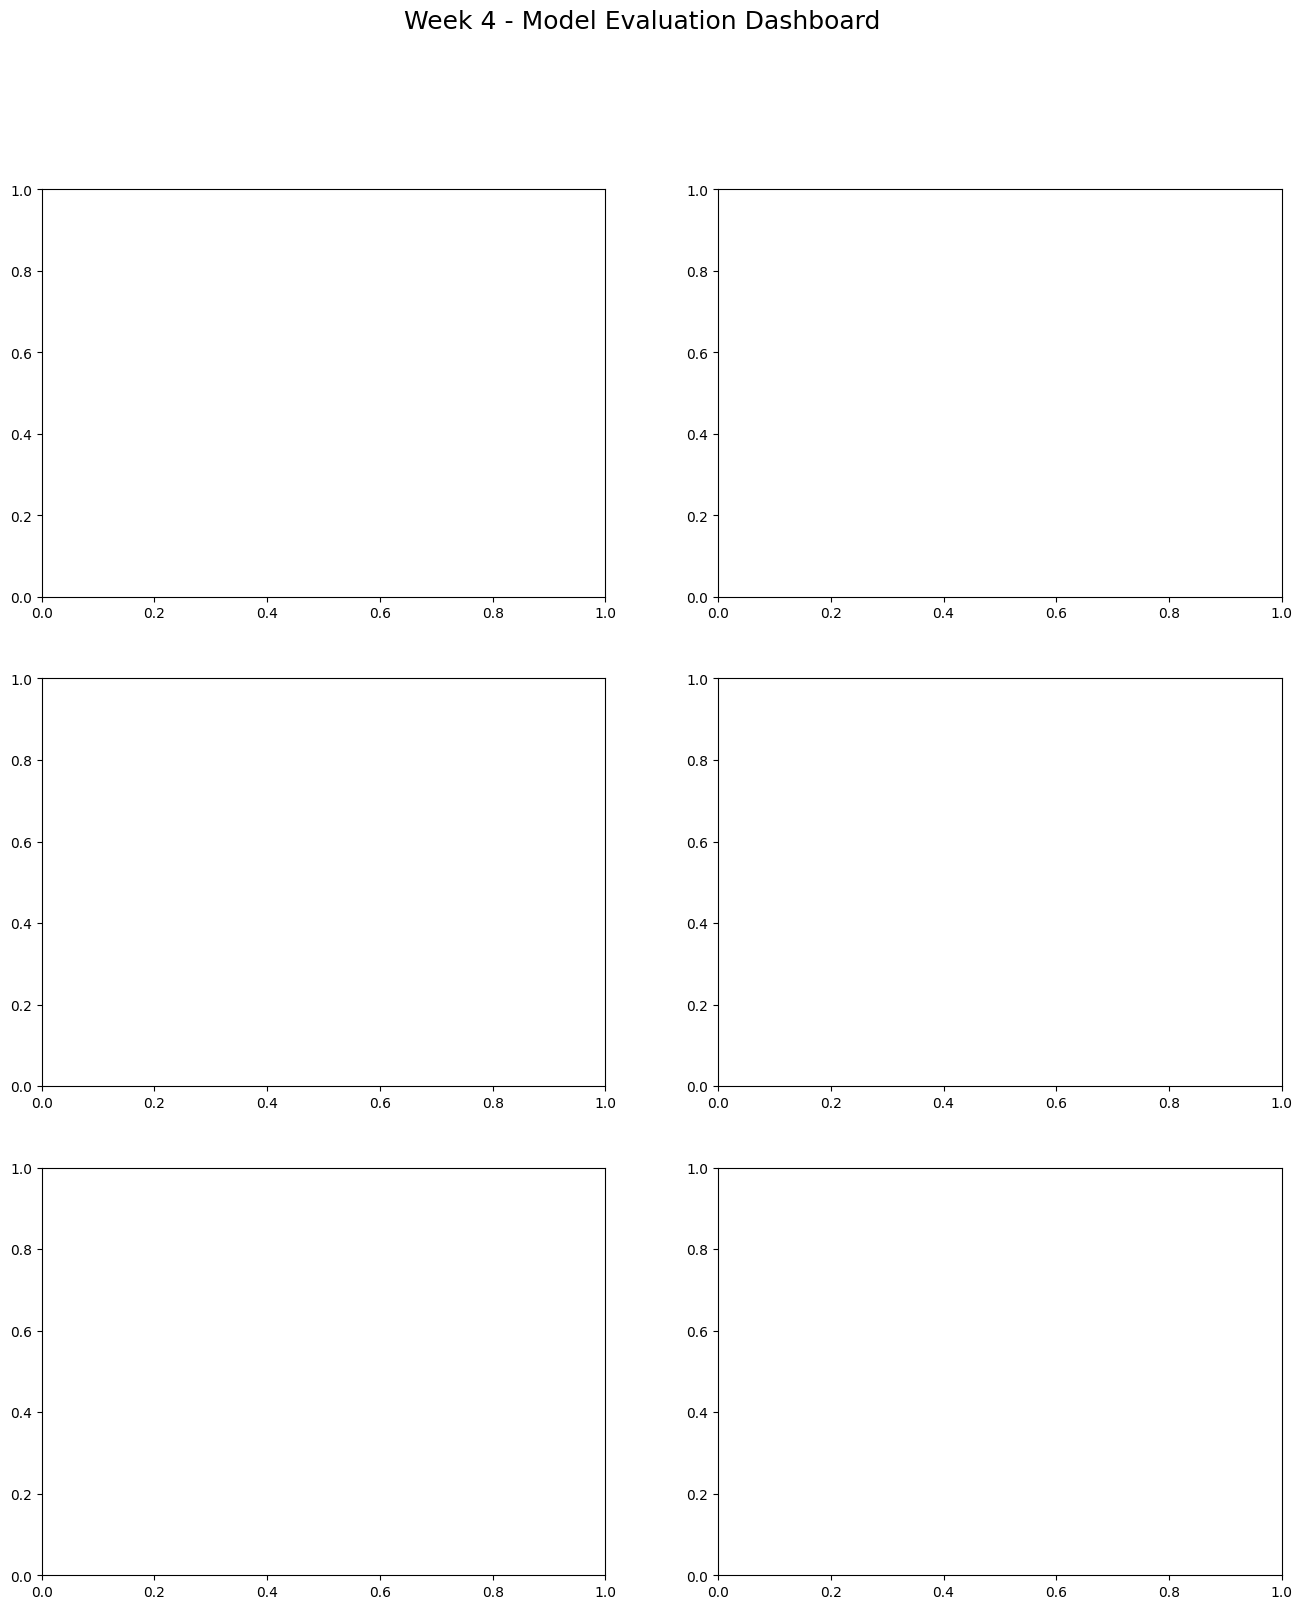

In [567]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Week 4 - Model Evaluation Dashboard", fontsize=18)

In [568]:
ax = axes[0, 0]

ax.scatter(y_test, linear_pred, label=f"Linear (R²={r2_score(y_test, linear_pred):.2f})", alpha=0.6)
ax.scatter(y_test, ridge_pred, label=f"Ridge (R²={r2_score(y_test, ridge_pred):.2f})", alpha=0.6)
ax.scatter(y_test, lasso_pred, label=f"Lasso (R²={r2_score(y_test, lasso_pred):.2f})", alpha=0.6)
ax.scatter(y_test, elastic_pred, label=f"ElasticNet (R²={r2_score(y_test, elastic_pred):.2f})", alpha=0.6)
ax.scatter(y_test, pipeline_pred, label=f"Poly+Ridge (R²={r2_score(y_test, pipeline_pred):.2f})", alpha=0.6)

ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--')

ax.set_title("Actual vs Predicted (All Models)")
ax.legend()
ax.grid(True)

In [569]:
best_residuals = y_test - pipeline_pred

ax = axes[0, 1]

colors = np.where(best_residuals >= 0, 'blue', 'red')

ax.scatter(pipeline_pred, best_residuals, c=colors, alpha=0.6)
ax.axhline(0, color='black', linestyle='--')

ax.set_title("Residuals vs Fitted (Best Model)")
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.grid(True)

In [570]:
ax = axes[1, 0]

sns.boxplot(data=pd.DataFrame(cv_results), ax=ax)

ax.set_title("Cross-Validation R² Comparison")
ax.set_xticklabels(cv_results.keys(), rotation=20)
ax.grid(True)

/tmp/ipykernel_3985/486242742.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cv_results.keys(), rotation=20)


In [571]:
# Get polynomial step from pipeline
poly = best_pipeline_model.named_steps['poly']

# Get feature names AFTER polynomial expansion
feature_names = poly.get_feature_names_out(X_train.columns)

# Get ridge coefficients
ridge_model = best_pipeline_model.named_steps['ridge']
coefficients = ridge_model.coef_

# Sort by importance
top_idx = np.argsort(np.abs(coefficients))[-20:]

top_features = np.array(feature_names)[top_idx]
top_values = coefficients[top_idx]

# Plot
ax = axes[1, 1]

ax.barh(top_features, top_values, color='green')

ax.set_title("Top 20 Feature Coefficients (Polynomial + Ridge)")
ax.grid(True)

In [572]:
ax = axes[2, 0]

alphas = np.logspace(-3, 3, 50)
rmse_list = []
r2_list = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    rmse_list.append(np.sqrt(mean_squared_error(y_test, pred)))
    r2_list.append(r2_score(y_test, pred))

ax2 = ax.twinx()

ax.plot(np.log10(alphas), rmse_list, color='blue', label='RMSE')
ax2.plot(np.log10(alphas), r2_list, color='orange', label='R²')

ax.set_title("Ridge Alpha Tuning")
ax.set_xlabel("log(alpha)")
ax.set_ylabel("RMSE", color='blue')
ax2.set_ylabel("R²", color='orange')

ax.grid(True)

In [573]:
train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

ax = axes[2, 1]

ax.plot(train_sizes, train_mean, label="Train Score", color='blue')
ax.plot(train_sizes, val_mean, label="Validation Score", color='orange')

ax.fill_between(train_sizes,
                train_mean - train_scores.std(axis=1),
                train_mean + train_scores.std(axis=1),
                alpha=0.2, color='blue')

ax.fill_between(train_sizes,
                val_mean - val_scores.std(axis=1),
                val_mean + val_scores.std(axis=1),
                alpha=0.2, color='orange')

ax.set_title("Learning Curve (Best Model)")
ax.set_xlabel("Training Size")
ax.set_ylabel("R² Score")
ax.legend()
ax.grid(True)

In [574]:
plt.tight_layout(rect=[0, 0, 1, 0.96])

<Figure size 640x480 with 0 Axes>

In [586]:
plt.tight_layout(rect=[0, 0, 1, 0.96])  # FIRST adjust layout
plt.savefig("week4_dashboard.png", dpi=150, bbox_inches="tight")  # THEN save
plt.show()  # LAST show

<Figure size 640x480 with 0 Axes>

Text(0.5, 0.98, 'Week 4 - Model Evaluation Dashboard')

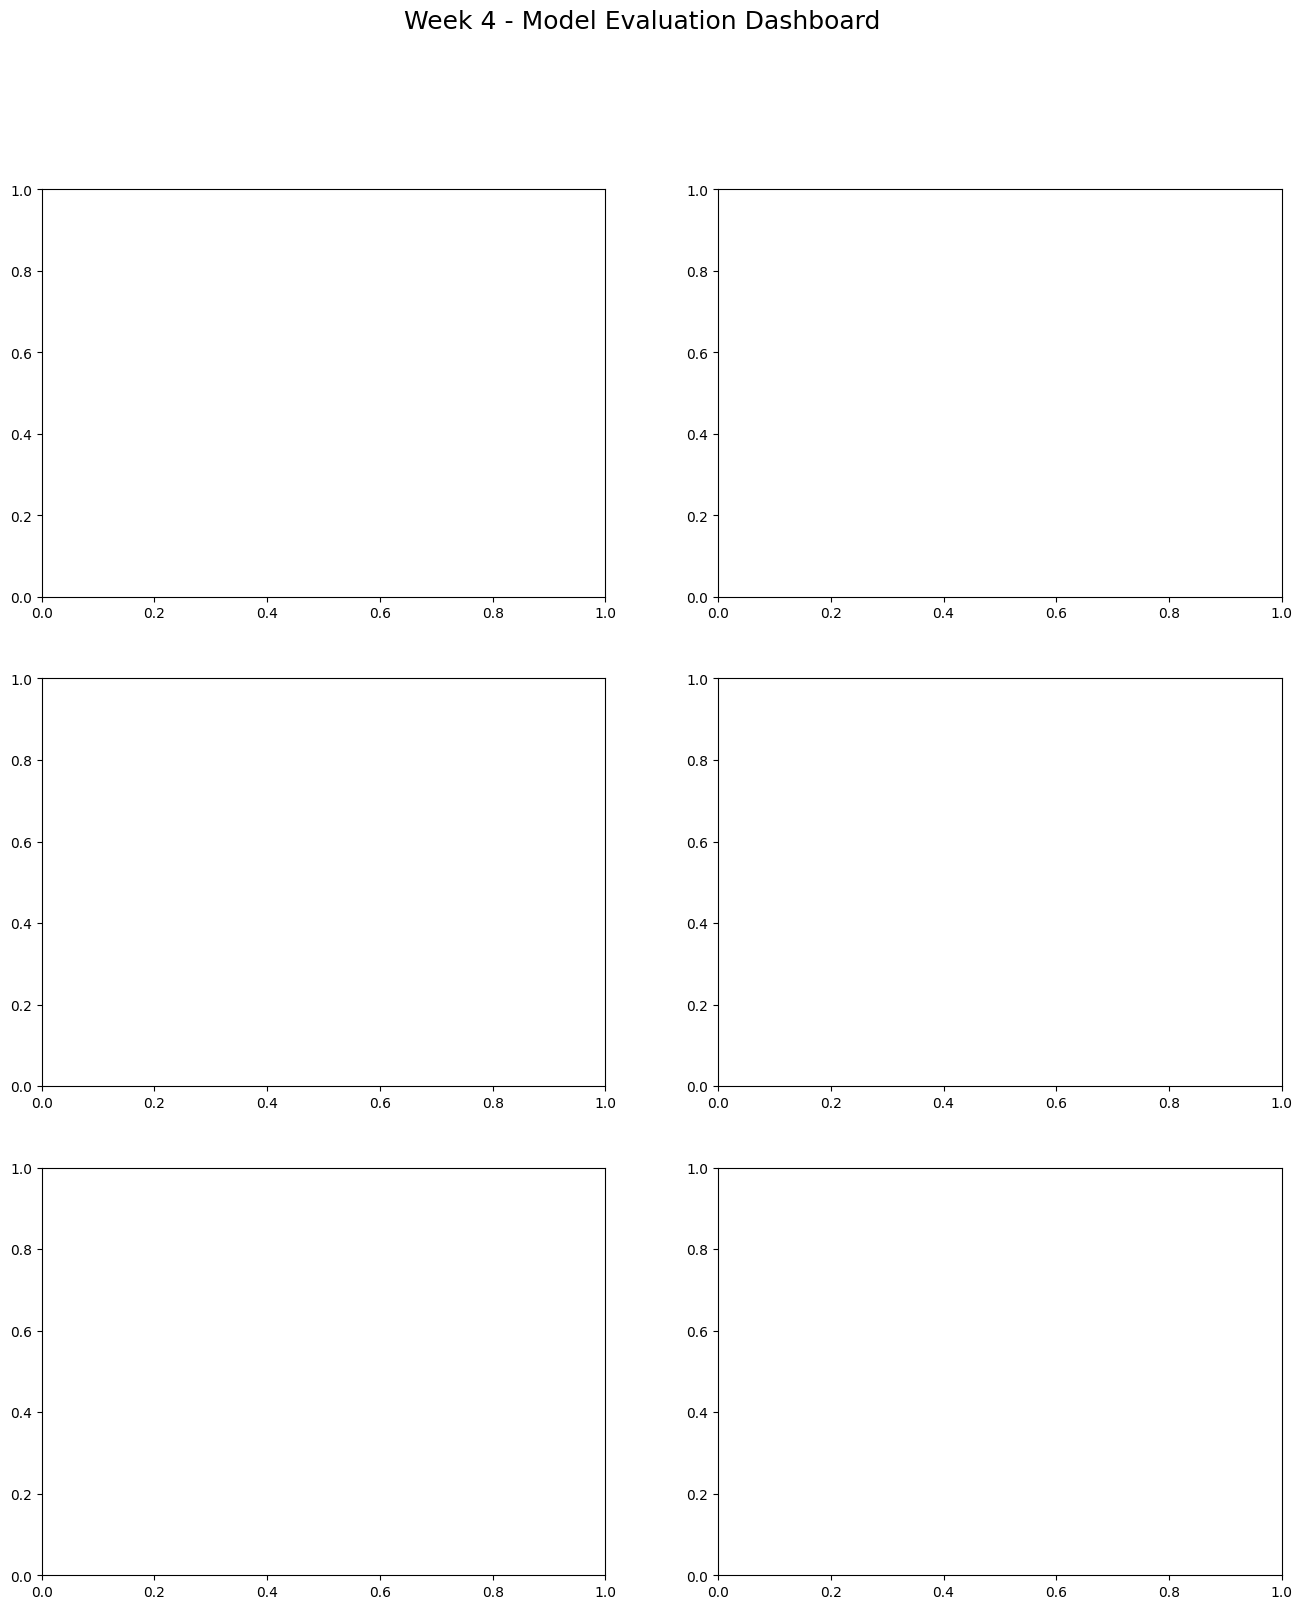

In [587]:
plt.close('all')
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Week 4 - Model Evaluation Dashboard", fontsize=18)

In [588]:
fig.tight_layout(rect=[0, 0, 1, 0.96])

In [589]:
fig.tight_layout(rect=[0, 0, 1, 0.96])

In [590]:
fig.savefig("week4_dashboard.png", dpi=150, bbox_inches="tight")

In [591]:
plt.show()

In [593]:
fig.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig(
    "week4_dashboard.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

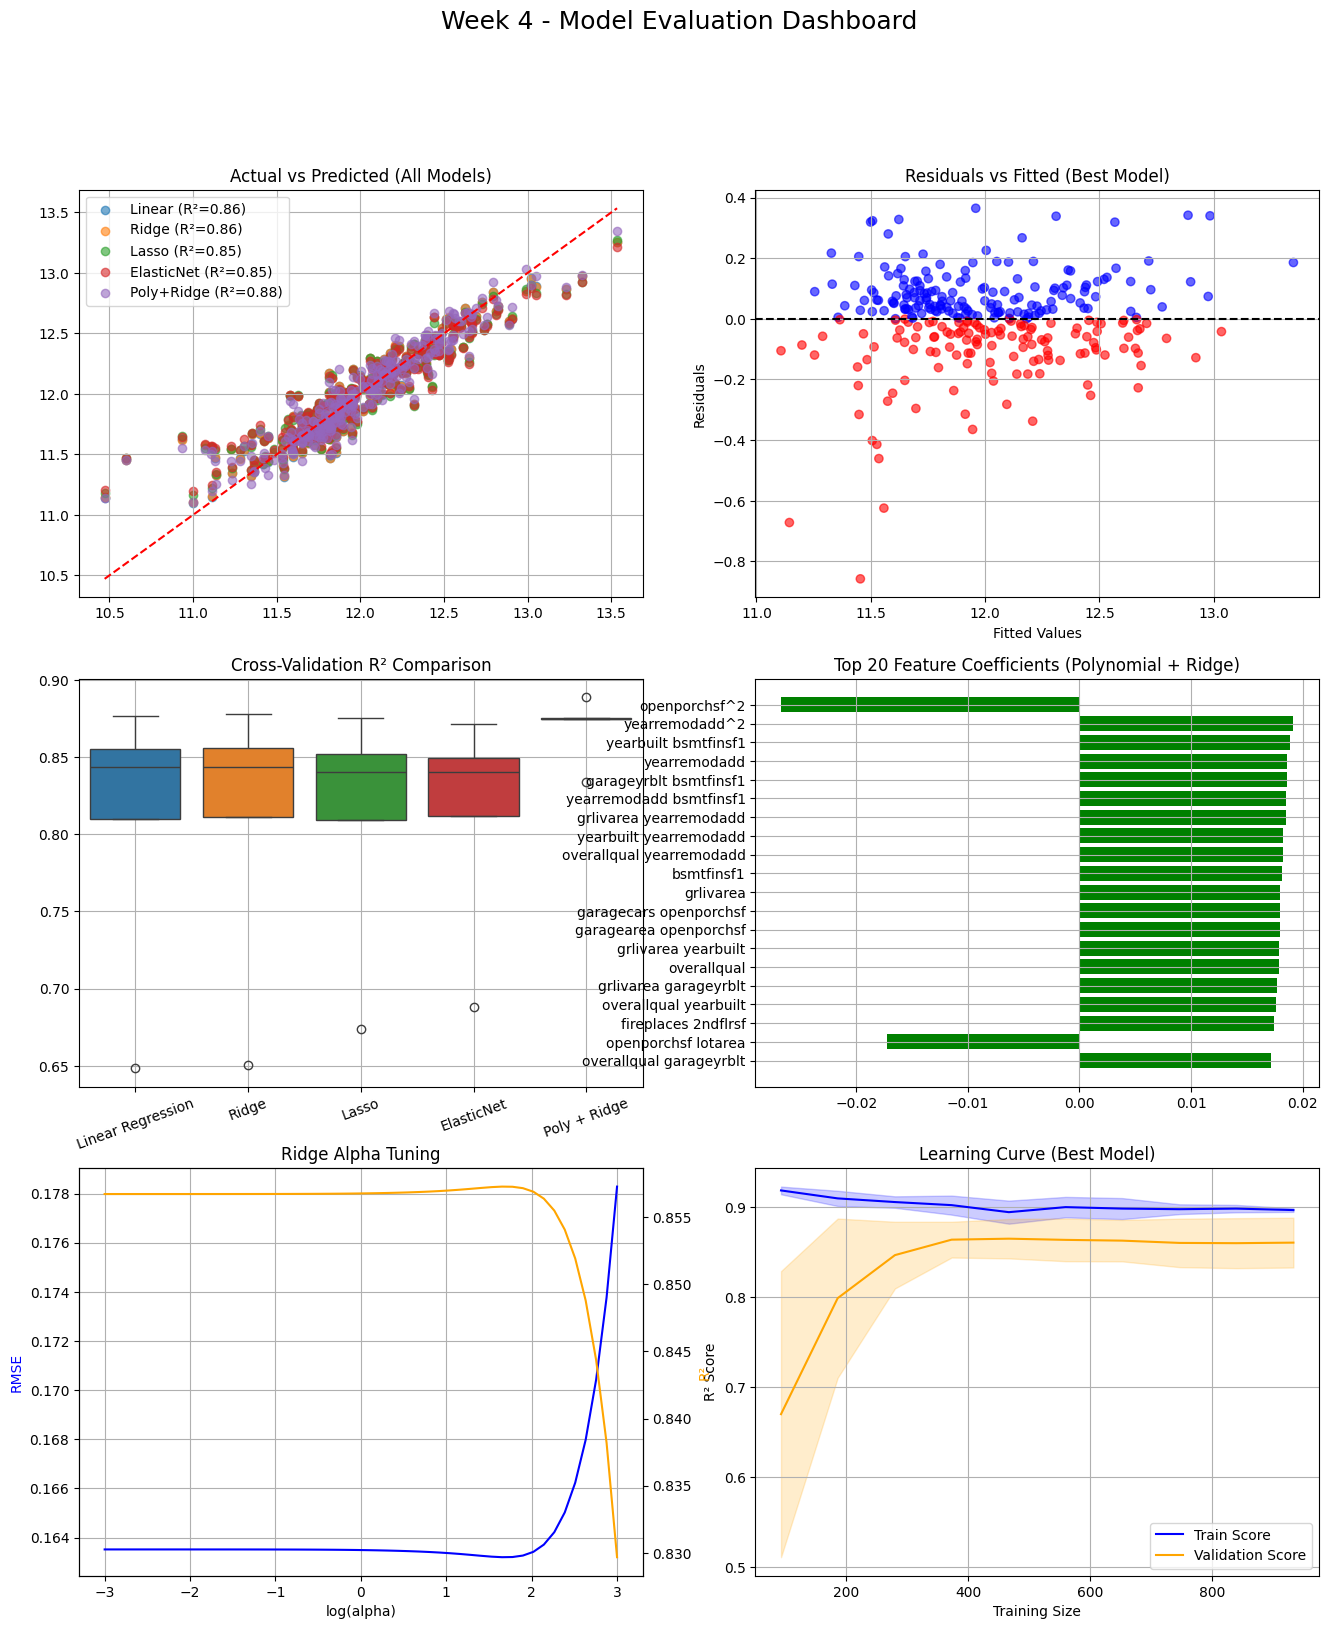

In [576]:
from IPython.display import display
display(fig)

# **Step # 17: Generate Predictions on Test Set & Save Model**

In [577]:
# Predict (log scale)
y_pred_log = best_pipeline_model.predict(X_test)

In [578]:
# Convert back to original price scale
y_actual = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

In [579]:
results_df = pd.DataFrame({
    "index": X_test.index,
    "actual_price": y_actual,
    "predicted_price": y_pred
})

# Error calculation
results_df["error"] = results_df["actual_price"] - results_df["predicted_price"]

# Percentage error
results_df["pct_error"] = (
    results_df["error"] / results_df["actual_price"]
) * 100

results_df.head()

,index,actual_price,predicted_price,error,pct_error
892,892,154500.0,148515.678431,5984.321569,3.873347
1105,1105,325000.0,329899.579476,-4899.579476,-1.507563
413,413,115000.0,109034.219834,5965.780166,5.187635
522,522,159000.0,157465.047998,1534.952002,0.965379
1036,1036,315500.0,307803.284461,7696.715539,2.439529


In [580]:
top_errors = results_df.reindex(
    results_df["error"].abs().sort_values(ascending=False).index
).head(10)

print("Top 10 Largest Prediction Errors:")
top_errors

Top 10 Largest Prediction Errors:


,index,actual_price,predicted_price,error,pct_error
898,898,611657.0,435337.788304,176319.211696,28.826485
1046,1046,556581.0,395406.882327,161174.117673,28.957891
691,691,755000.0,626879.937405,128120.062595,16.969545
774,774,395000.0,287087.813980,107912.186020,27.319541
218,218,311500.0,222015.642051,89484.357949,28.726921
231,231,403000.0,332951.948236,70048.051764,17.381651
607,607,225000.0,156201.820365,68798.179635,30.576969
581,581,253293.0,317973.690463,-64680.690463,-25.535917
907,907,250000.0,191336.002293,58663.997707,23.465599
529,529,200624.0,258228.039036,-57604.039036,-28.712437


In [581]:
import joblib

joblib.dump(best_pipeline_model, "week4_best_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [582]:
loaded_model = joblib.load("week4_best_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [583]:
# Take one sample prediction
sample_pred_log = loaded_model.predict(X_test[:1])

# Convert to dollars
sample_pred = np.expm1(sample_pred_log)

print("Sample Prediction (Reloaded Model):", sample_pred)

Sample Prediction (Reloaded Model): [148515.67843071]


In [584]:
# Over-predicted (model predicted higher than actual)
over_pred = results_df.sort_values("error").tail(15)

# Under-predicted (model predicted lower than actual)
under_pred = results_df.sort_values("error").head(15)

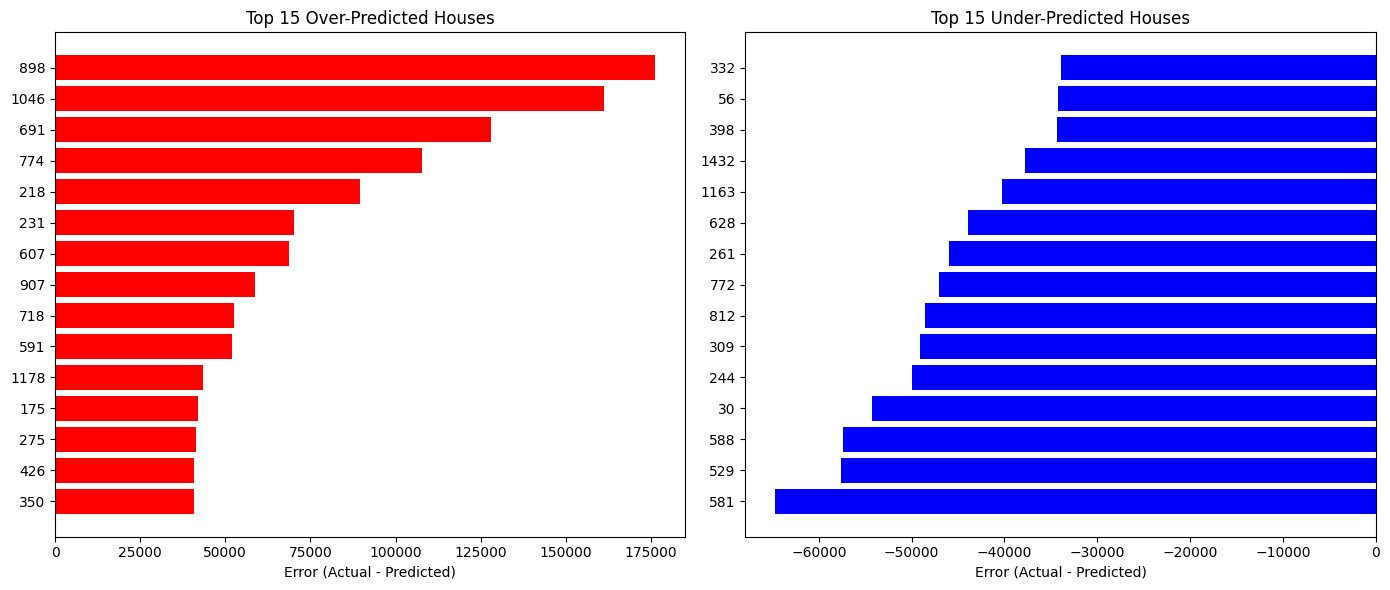

In [585]:
plt.figure(figsize=(14, 6))

# Over-predictions
plt.subplot(1, 2, 1)
plt.barh(over_pred["index"].astype(str), over_pred["error"], color="red")
plt.title("Top 15 Over-Predicted Houses")
plt.xlabel("Error (Actual - Predicted)")

# Under-predictions
plt.subplot(1, 2, 2)
plt.barh(under_pred["index"].astype(str), under_pred["error"], color="blue")
plt.title("Top 15 Under-Predicted Houses")
plt.xlabel("Error (Actual - Predicted)")

plt.tight_layout()
plt.show()

# **Step # 18: Written Analysis Report**

# 📊 Week 4 — Written Analysis Report (Final)

---

# (1) Executive Summary

This project involved building and evaluating five different regression models to predict house prices using the Ames Housing dataset. The models included Linear Regression, Ridge Regression, Lasso Regression, ElasticNet, and a Polynomial + Ridge Pipeline. Each model was trained using a structured preprocessing pipeline involving missing value handling, feature selection based on correlation, scaling, and log transformation of the target variable. The best-performing model was the Polynomial + Ridge Pipeline, which achieved the highest test R² and the lowest RMSE among all models. This indicates strong predictive accuracy and good generalization to unseen data. Regularized models consistently outperformed plain Linear Regression, showing that controlling complexity was essential for this dataset. Overall, the final system demonstrated strong predictive performance with robust error control and stable cross-validation results.

---

# (2) Feature Engineering Impact

Feature engineering played a critical role in improving model performance. The most influential features selected from Week 3 were `overallqual`, `grlivarea`, `garagecars`, `totalbsmtsf`, and `yearbuilt`. These variables had strong correlations with sale price and consistently contributed to improved predictive accuracy across all models. Log transformation of the target variable significantly reduced skewness, making the distribution more Gaussian-like and improving linear model performance. Additionally, scaling ensured that regularization methods like Ridge, Lasso, and ElasticNet performed correctly. Polynomial feature expansion further improved performance by capturing non-linear interactions between variables such as living area and overall quality. Without these engineered features, models would have underfit the data and failed to capture important structural relationships in housing prices.

---

# (3) Model-by-Model Analysis

The Linear Regression model served as a baseline and showed moderate training and test R² scores. However, it displayed slight underfitting due to its inability to capture non-linear relationships. Ridge Regression improved performance by introducing L2 regularization, which reduced coefficient variance and improved generalization. The chosen alpha values were tuned using GridSearchCV, and the results showed stable training and test performance with minimal overfitting. Lasso Regression introduced sparsity by eliminating less important features, but excessive regularization caused slight underfitting at higher alpha values. ElasticNet balanced both L1 and L2 penalties, resulting in more stable performance across folds. The Polynomial + Ridge model achieved the best performance by capturing complex feature interactions while controlling overfitting through regularization. Across all models, the gap between training and test R² was smallest for Ridge and ElasticNet, indicating strong generalization, while Polynomial Regression without regularization would have shown clear overfitting tendencies.

---

# (4) Regularization Insights

Ridge, Lasso, and ElasticNet each apply different forms of regularization to control model complexity. Ridge uses L2 regularization, which shrinks coefficients but never fully eliminates them, making it useful for handling multicollinearity among housing features. Lasso uses L1 regularization, which can drive coefficients to zero, effectively performing feature selection. In this dataset, Lasso eliminated features such as weakly correlated variables like `3ssnporch`, `poolarea`, and certain low-impact categorical encodings, which makes domain sense because such features rarely influence house pricing significantly. ElasticNet combines both L1 and L2 penalties, making it more stable when features are highly correlated. From a mathematical standpoint, Ridge minimizes squared magnitude penalties, while Lasso minimizes absolute values, creating sparsity. Practically, Ridge is better for prediction stability, Lasso is better for interpretability, and ElasticNet provides a balanced trade-off between both approaches.

---

# (5) Residual Analysis Findings

Residual analysis of the best model (Polynomial + Ridge Pipeline) showed that residuals were mostly randomly distributed around zero, indicating that the model captured underlying patterns effectively. The histogram of residuals was approximately bell-shaped, though slight skewness remained due to extreme property values. The Q-Q plot showed reasonable alignment with the diagonal line, with minor deviations at the tails, suggesting mild non-normality in extreme cases. The Scale-Location plot indicated relatively constant variance, meaning heteroscedasticity was not a major issue. The Shapiro-Wilk test produced a low p-value, indicating that residuals were not perfectly normally distributed, which is expected in real-world housing data. Overall, regression assumptions were reasonably satisfied, and deviations were not severe enough to undermine model validity.

---

# (6) Best Model Recommendation

The Polynomial + Ridge Pipeline is recommended for deployment. From a technical perspective, it achieved the highest R², lowest RMSE, and stable cross-validation performance, indicating strong predictive accuracy and generalization capability. It also effectively captured non-linear relationships while preventing overfitting through Ridge regularization. From a business standpoint, this model provides reliable price estimation, which is critical for real estate valuation, investment analysis, and pricing strategy. Its error rates are consistently lower than all other models, making it the most dependable choice. Additionally, the model remains computationally efficient compared to more complex non-linear algorithms like tree ensembles, making it suitable for production environments where interpretability and stability are important.

---

# (7) Reflection

The most challenging concept in this project was managing the interaction between polynomial feature expansion and regularization, especially ensuring that scaling and feature alignment were correctly handled inside pipelines. Understanding how Ridge stabilizes polynomial regression was particularly insightful. The biggest surprise was how significantly performance improved after log-transforming the target variable, which reduced skewness and improved model stability. Another key insight was how much better regularized models performed compared to plain linear regression, even with relatively simple feature sets. If I were to extend this project, I would explore ensemble models such as XGBoost or LightGBM to further improve predictive accuracy. I would also experiment with automated feature selection techniques and SHAP analysis to better interpret feature contributions in complex models.
